# Investigating Vibrant Planet's California Structure Graph Data

Kathryn Wheeler, Ph.D.

Data from: https://www.vpdatacommons.org/datasets/ca-stucture-graph-data
Data story: https://www.vpdatacommons.org/data-story/ca-structure-graph

## Overall exploratory questions:
* How much data is there? And general summary statistics?
* How much is in areas where building connectivity matters? Determined by filtering out buildings in areas of substantial tree cover or in the wildlands determined in the Riley et al. (2025) paper. 
* Correlations between variables? Which ones might be kept and used vs which are repetitive?
* For several interesting counties check to make sure the connectivity attributes are not highly correlated with Open Climate Risk's current risk estimates. If they are highly correlated it would be hard to find signals of structure connectivity impacting fire risk. 

## Notes about data download. 
To fully run this notebook from scratch, data must be downloaded and placed inside a "Data" folder within this repo. The code is set up to download data when missing to this repo, with a couple exceptions:
* Structure graph node data from: https://www.vpdatacommons.org/datasets/ca-stucture-graph-data
* Zip file of data from Riley et al. (2025): https://www.fs.usda.gov/rds/archive/catalog/RDS-2025-0006
* Open Climate Risk's data for counties Mariposa, Shasta, and Sacramento

An additional note about data download, most of these I would have downloaded via Google Earth Engine, but decided to download them from the source here so that it is easier for someone else to replicate without having to create a GEE project and authenticate it. 

Claude Code helped with some of the small step coding such as formatting tables/figures after being directed or fixing bugs. The direction, questions, ideas, and what to investigate was all done by Kathryn. Claude Code also helped with general cleanup of the repo such as drafting the README. 

## Import libraries, set some constants, define file paths

In [35]:
%load_ext autoreload
%autoreload 2
    
import geopandas as gpd
import matplotlib.pyplot as plt
from node_summaries import summarize_nodes
from landcover import mean_tree_canopy
from risk_correlations import correlate_connectivity_with_risk
from pathlib import Path
from shapely.geometry import Point
import pandas as pd
import rasterio
import numpy as np
from rasterio.windows import from_bounds
from scipy.ndimage import distance_transform_edt
from matplotlib.ticker import StrMethodFormatter
from scipy.stats import spearmanr
from risk_correlations import correlate_connectivity_with_risk
from scipy.stats import spearmanr
from node_summaries import HIST_SETTINGS

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

DATA_DIR = "Data/" #Directory where data is stored
county_file = Path("Data/ca_counties.gpkg")
county_url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"

veg_year = 2025  #Year to pull tree canopy cover data for
radius_m = 100    #Neighborhood around each building; matches the graph's 100 m cutoff

tcc_url = (
    "/vsizip/vsicurl/https://data.fs.usda.gov/geodata/rastergateway/treecanopycover/docs/v2025-6/"
    f"nlcd_tcc_conus_{veg_year}_v2025-6_wgs84.zip/nlcd_tcc_conus_wgs84_v2025-6_{veg_year}0101_{veg_year}1231.tif"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read in node data, look for missing data, general summary statistics

102,461 nodes with no objectid. Number of them with a value in each column:
objectid                0
degree_100              0
degree_50               0
degree_10               0
clustering_coef         0
mean_ssd                0
min_ssd                 0
geometry           102461
Non-empty footprints: 102,461
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 13527672 entries, 0 to 13527671
Data columns (total 8 columns):
 #   Column           Dtype   
---  ------           -----   
 0   objectid         str     
 1   degree_100       float64 
 2   degree_50        float64 
 3   degree_10        float64 
 4   clustering_coef  object  
 5   mean_ssd         float64 
 6   min_ssd          float64 
 7   geometry         geometry
dtypes: float64(5), geometry(1), object(1), str(1)
memory usage: 1.2+ GB


### Summary of all 13,527,672 buildings

,count,missing,decimal_places,mean,median,std,min,25%,75%,max
degree_10,"13,527,672",0,0,2.294,2.000,1.646,0.000,1.000,3.000,65.000
degree_50,"13,527,672",0,0,15.602,15.000,9.656,0.000,9.000,21.000,167.000
degree_100,"13,527,672",0,0,45.690,43.000,28.845,1.000,25.000,62.000,323.000
clustering_coef,"13,325,904","201,768",1,0.642,0.600,0.118,0.000,0.600,0.700,1.000
mean_ssd,"13,527,672",0,more than 6,58.768,60.242,8.608,0.000,56.770,62.942,99.988
min_ssd,"13,527,672",0,more than 6,5.719,2.674,9.912,0.000,1.565,5.285,99.988


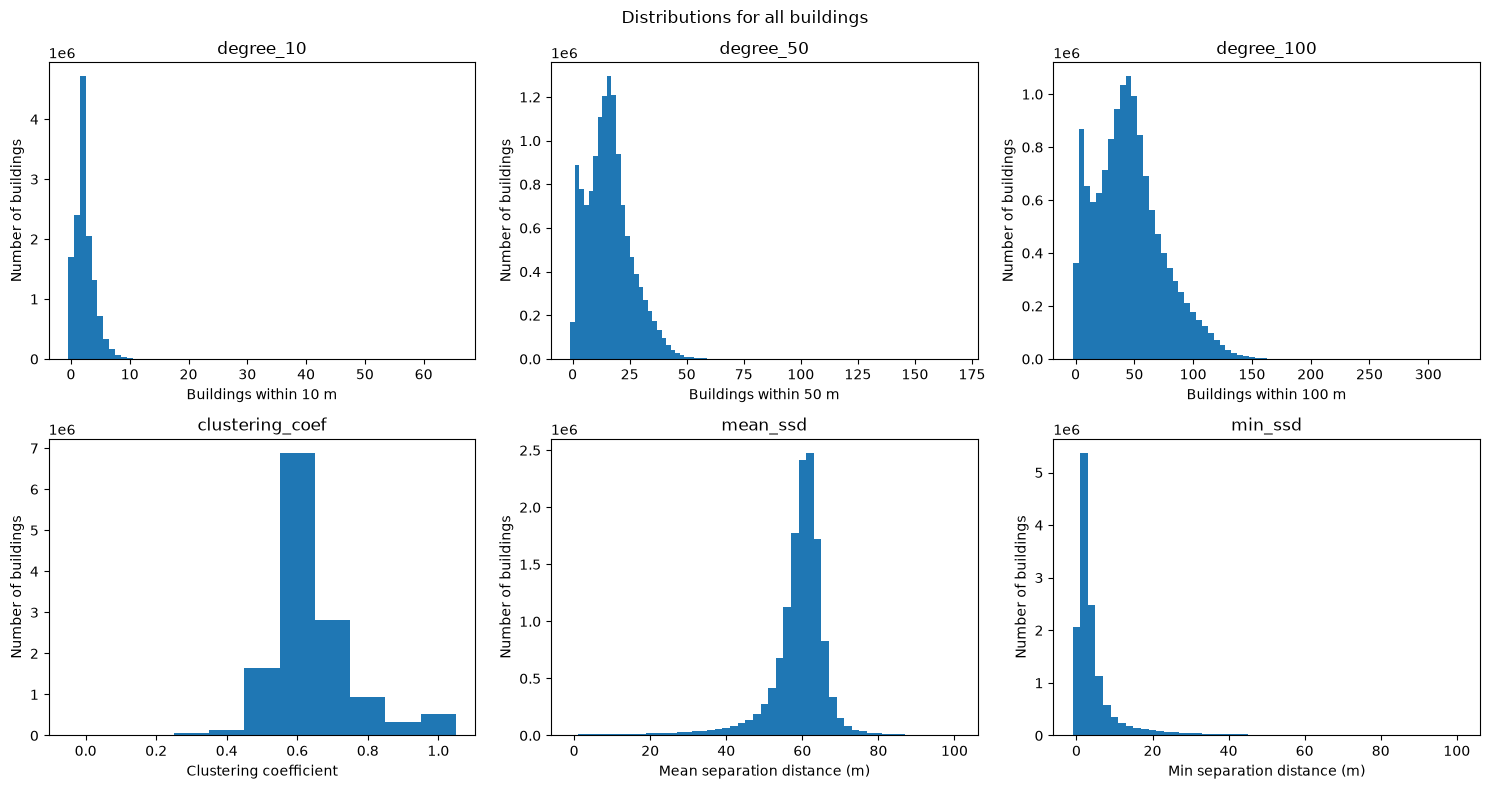

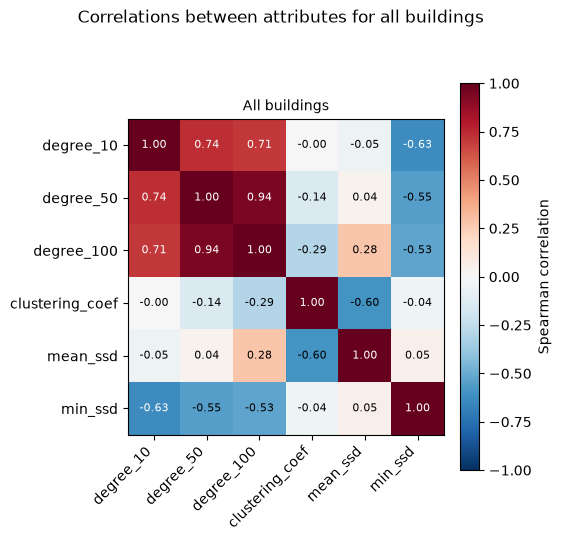

In [10]:
#Read in node data
nodes = gpd.read_parquet("Data/ca_vpdc_nodes.parquet")

#Brief investigation into nodes with no objectid before removing them
no_id = nodes["objectid"].isna()
print(f"{no_id.sum():,} nodes with no objectid. Number of them with a value in each column:")
print(nodes.loc[no_id].notna().sum().to_string())
print(f"Non-empty footprints: {(~nodes.loc[no_id].geometry.is_empty).sum():,}")

#Remove nodes with no objectid. These ~102k rows (0.75%) also have no graph stats (degree,
#clustering coefficient, SSD); they only have a footprint. I am not certain why they are missing, but it is likely they just do not
#have any buildings within 100 m of them to connect. Of the rows with objectid they all have at least 1 building within 100 m.
#These buildings do not need objectid's to connect them to buildings in the edge files because they are not connected to other buildings.

no_id_nodes = nodes.loc[no_id, ["geometry"]].reset_index(drop=True) #Keep them to make sure they are not clustered in a county later
nodes = nodes[~no_id].reset_index(drop=True)

nodes.info()
nodes.head()

nodes["clustering_coef"] = nodes["clustering_coef"].astype(float) #clustering_coef is stored as a decimal type, convert to float

#General summary statistics
overall_summary = summarize_nodes(nodes)

After removing the rows missing objected values, the only attribute missing data is the clustering_coef. The degree_* attributes are whole numbers, which makes sense because they are counts. The clustering coefficient is between 0 and 1, which a precision of 1 decimal. The mean and min ssd have a lot finer precisions. The degree_* attributions are right-skewed. Clustering_coef, mean_ssd visually somewhat normal. Min_ssd is right-skewed. 

As expected, the degree_10 and degree_50, and degree_100  are all decently correlated but degree_50 and degree_100 are too correlated to be included in the same basic analysis (0.94 spearman correlation). Mean_ssd and clustering_coef are decently negatively correlated (-0.60) and the clustering_coef has essentially no correlation with degree_10 and weak negative correlations with degree_50 and degree_100 (-0.00, -0.14, -0.29).

58 counties


<Axes: >

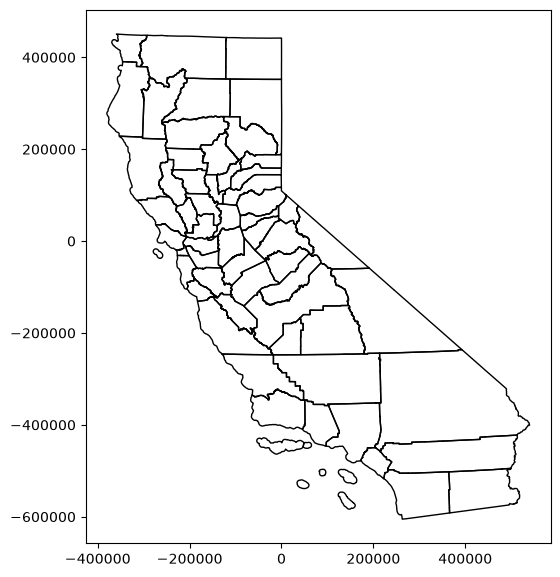

In [42]:
if county_file.exists(): #If the county file has already been downloaded read it in, if not download it
    counties = gpd.read_file(county_file)
else:
    #Census TIGER/Line county boundaries for the US, filtered to California (state FIPS 06).
    counties = gpd.read_file(county_url)
    counties = counties[counties["STATEFP"] == "06"][["GEOID", "NAME", "geometry"]]
    counties = counties.rename(columns={"GEOID": "county_fips", "NAME": "county"})
    # match the nodes' coordinate system (California Albers)
    counties = counties.to_crs(nodes.crs)
    counties.to_file(county_file)

print(len(counties), "counties")
counties.plot(edgecolor="black", facecolor="none", figsize=(6, 7)) #Plot to make sure they look right

## Differences between ecoregions. Which are the most common types?

15 ecoregions


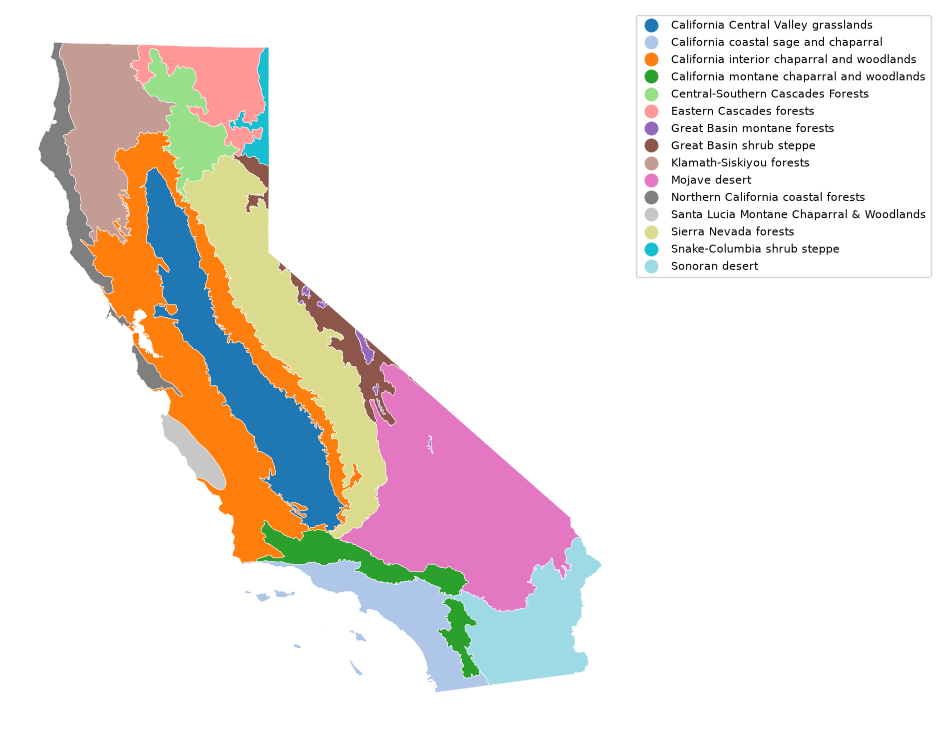

In [3]:
#Read in RESOLVE ecoregions for California
ecoregion_file = Path("Data/ca_ecoregions.gpkg")

if ecoregion_file.exists():
    ecoregions = gpd.read_file(ecoregion_file)
else:
    # RESOLVE Ecoregions 2017 shapefile for the world (~150 MB zip).
    # Downloads once, then saves a California-only copy in Data/ for next time.
    url = "https://storage.googleapis.com/teow2016/Ecoregions2017.zip"
    # bbox (lon/lat) only reads ecoregions near California instead of the whole world
    ecoregions = gpd.read_file(url, bbox=(-124.5, 32.5, -114.0, 42.1))
    ecoregions = ecoregions[["ECO_ID", "ECO_NAME", "BIOME_NAME", "geometry"]]
    # match the nodes' coordinate system (California Albers)
    ecoregions = ecoregions.to_crs(nodes.crs)
    # some polygons in this dataset have invalid geometry, which breaks clipping;
    # "structure" with keep_collapsed=False fixes them and keeps only polygon pieces
    ecoregions["geometry"] = ecoregions.geometry.make_valid(method="structure", keep_collapsed=False)
    # trim to the state outline, dropping any stray line/point slivers the clip creates
    ecoregions = gpd.clip(ecoregions, counties.dissolve(), keep_geom_type=True)
    ecoregions.to_file(ecoregion_file)

print(len(ecoregions), "ecoregions")
ax = ecoregions.plot(column="ECO_NAME", cmap="tab20", legend=True, edgecolor="white", linewidth=0.3, figsize=(8, 10),
                     legend_kwds={"loc": "upper left", "bbox_to_anchor": (1, 1), "fontsize": 8}) #Plot to make sure it looks right
ax.set_axis_off()

1203 nodes not in any ecoregion


### Number of nodes by ecoregion

,n_nodes,percent
ecoregion,,
California coastal sage and chaparral,"6,236,465",46.10
California interior chaparral and woodlands,"3,368,535",24.90
California Central Valley grasslands,"2,432,113",17.98
Mojave desert,"407,244",3.01
Sonoran desert,"313,551",2.32
Sierra Nevada forests,"253,885",1.88
Northern California coastal forests,"186,583",1.38
California montane chaparral and woodlands,"116,795",0.86
Santa Lucia Montane Chaparral & Woodlands,"61,670",0.46


### degree_10 by ecoregion (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
California coastal sage and chaparral,"6,236,465",0,2.720,2.000,1.703,0.000,2.000,4.000,50.000
California interior chaparral and woodlands,"3,368,535",0,2.263,2.000,1.681,0.000,1.000,3.000,65.000
nan,"1,203",0,2.177,2.000,2.192,0.000,1.000,3.000,16.000
Sonoran desert,"313,551",0,2.054,2.000,1.384,0.000,1.000,3.000,32.000
Santa Lucia Montane Chaparral & Woodlands,"61,670",0,2.038,2.000,1.656,0.000,1.000,3.000,15.000
California Central Valley grasslands,"2,432,113",0,1.824,2.000,1.196,0.000,1.000,2.000,38.000
Mojave desert,"407,244",0,1.398,1.000,1.206,0.000,0.000,2.000,26.000
Northern California coastal forests,"186,583",0,1.263,1.000,1.295,0.000,0.000,2.000,22.000
Great Basin shrub steppe,"28,790",0,1.091,1.000,1.163,0.000,0.000,2.000,9.000


...

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
California coastal sage and chaparral,"6,236,465",0,18.150,17.000,9.429,0.000,11.000,24.000,131.000
California interior chaparral and woodlands,"3,368,535",0,15.836,15.000,10.541,0.000,8.000,22.000,149.000
Santa Lucia Montane Chaparral & Woodlands,"61,670",0,13.480,12.000,9.935,0.000,5.000,21.000,69.000
Sonoran desert,"313,551",0,13.309,13.000,8.033,0.000,8.000,17.000,77.000
California Central Valley grasslands,"2,432,113",0,12.797,13.000,7.032,0.000,8.000,17.000,167.000
nan,"1,203",0,10.390,8.000,8.702,0.000,4.000,14.000,40.000
Mojave desert,"407,244",0,9.445,8.000,6.988,0.000,4.000,14.000,66.000
Northern California coastal forests,"186,583",0,8.386,6.000,7.269,0.000,2.000,13.000,79.000
Great Basin shrub steppe,"28,790",0,7.390,5.000,6.626,0.000,2.000,12.000,39.000


### clustering_coef by ecoregion (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
nan,"1,161",42,0.792,0.800,0.144,0.300,0.700,0.900,1.000
Snake-Columbia shrub steppe,"1,768",333,0.788,0.800,0.197,0.300,0.600,1.000,1.000
Klamath-Siskiyou forests,"41,109","9,072",0.772,0.800,0.200,0.200,0.600,1.000,1.000
Eastern Cascades forests,"29,776","4,098",0.750,0.700,0.193,0.100,0.600,1.000,1.000
Great Basin montane forests,167,15,0.746,0.700,0.169,0.300,0.600,0.900,1.000
Great Basin shrub steppe,"26,877","1,913",0.704,0.700,0.173,0.200,0.600,0.800,1.000
Northern California coastal forests,"176,239","10,344",0.698,0.700,0.165,0.200,0.600,0.800,1.000
Sierra Nevada forests,"231,651","22,234",0.688,0.700,0.182,0.100,0.600,0.800,1.000
California montane chaparral and woodlands,"110,669","6,126",0.684,0.600,0.164,0.100,0.600,0.800,1.000


### mean_ssd by ecoregion (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
ecoregion,,,,,,,,,
California coastal sage and chaparral,"6,236,465",0,59.807,60.577,6.002,0.000,57.595,63.056,99.965
California interior chaparral and woodlands,"3,368,535",0,58.529,60.210,9.194,0.000,56.524,62.978,99.988
Mojave desert,"407,244",0,58.003,59.810,11.047,0.000,55.422,63.076,99.981
California Central Valley grasslands,"2,432,113",0,57.719,59.813,9.741,0.000,56.137,62.507,99.981
Sonoran desert,"313,551",0,57.404,58.998,9.118,0.000,54.783,62.111,99.929
California montane chaparral and woodlands,"116,795",0,57.246,59.809,12.988,0.000,53.421,64.019,99.862
Santa Lucia Montane Chaparral & Woodlands,"61,670",0,57.024,59.586,11.634,0.000,54.657,62.855,99.930
Central-Southern Cascades Forests,"34,500",0,56.907,59.126,14.427,0.000,51.681,64.758,99.904
Sierra Nevada forests,"253,885",0,56.293,59.077,15.072,0.000,51.294,64.425,99.967


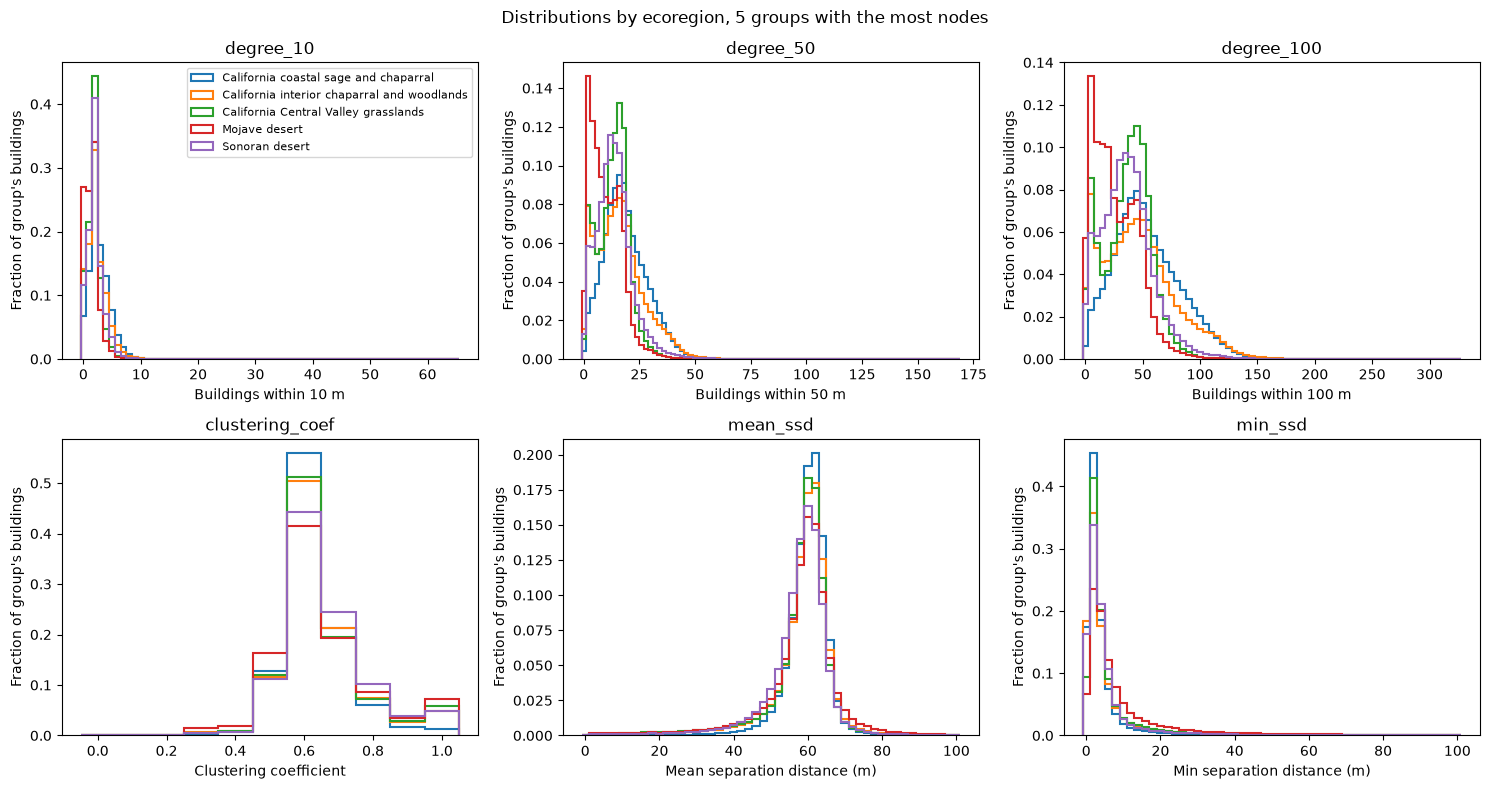

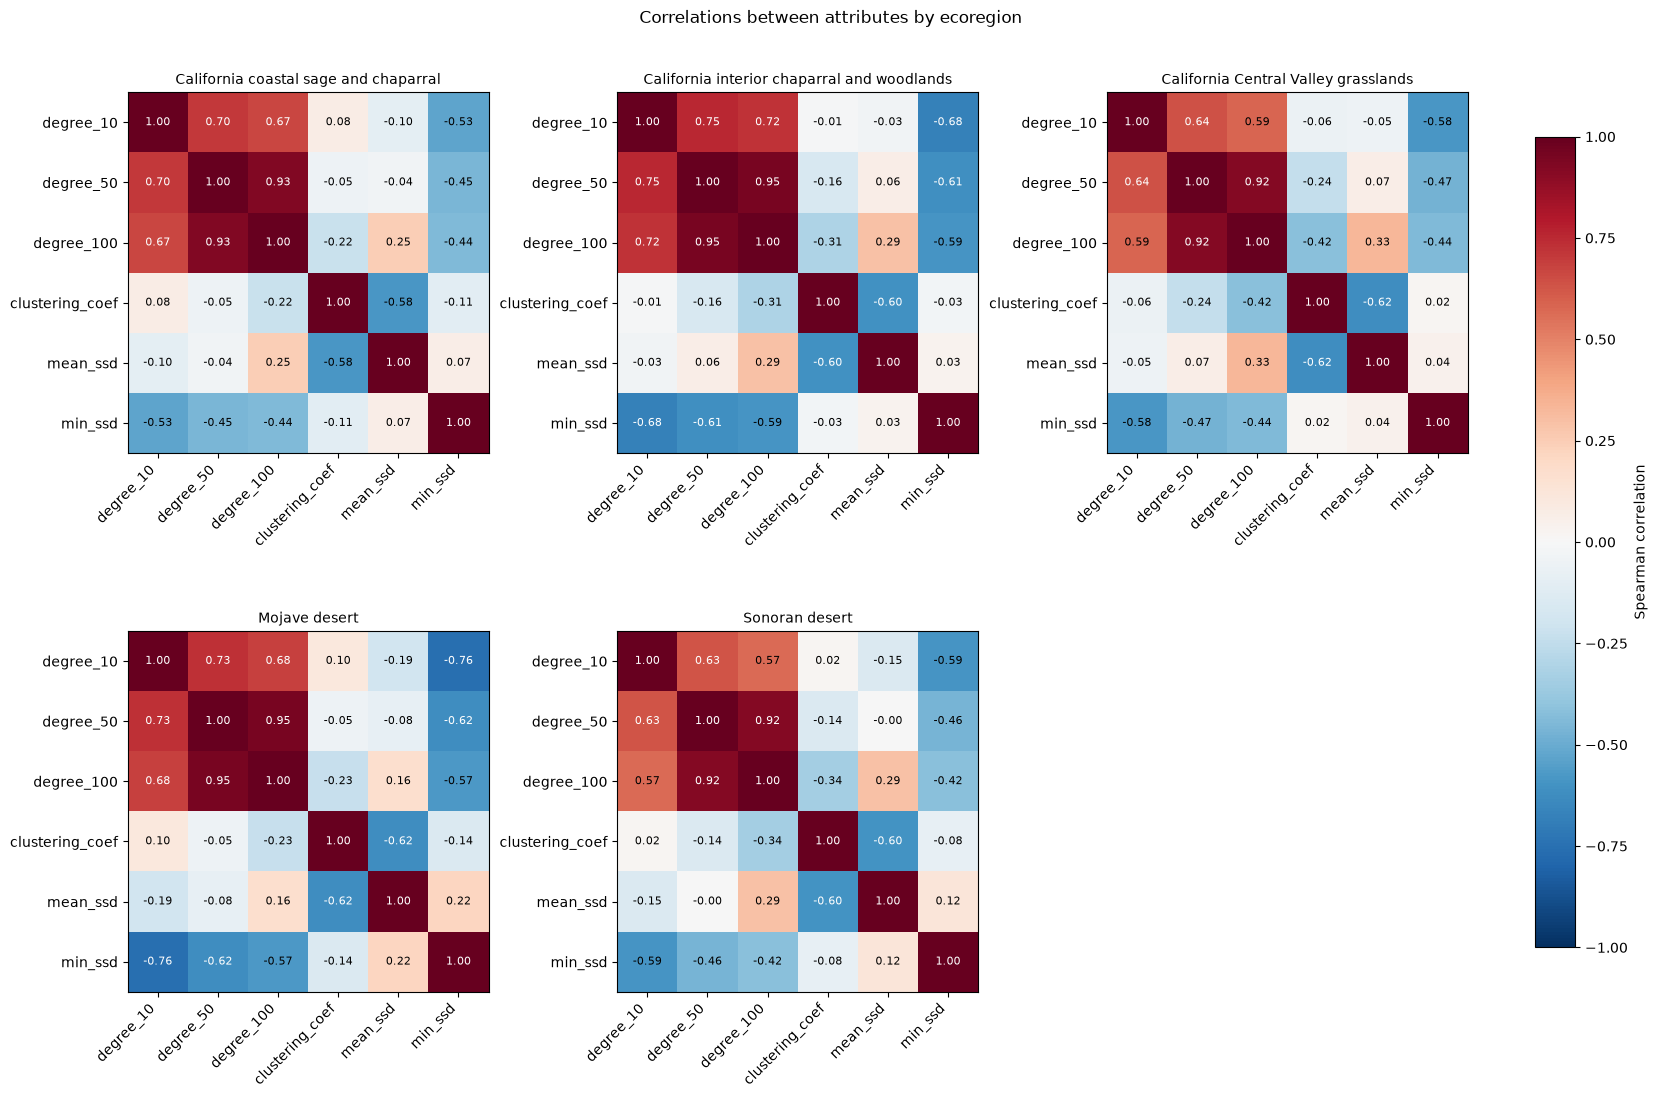

In [11]:
#Assign an ecoregion to each node

#Use one point inside each building footprint so every building gets exactly one ecoregion,
#even if its footprint crosses an ecoregion line
points = gpd.GeoDataFrame(geometry=nodes.geometry.representative_point(), crs=nodes.crs)

joined = gpd.sjoin(points, ecoregions, how="left", predicate="within") 

joined = joined[~joined.index.duplicated()] #Guard against a point matching two ecoregions (keeps the first match)

nodes["ecoregion"] = joined["ECO_NAME"]
nodes["biome"] = joined["BIOME_NAME"]

print(nodes["ecoregion"].isna().sum(), "nodes not in any ecoregion")

#Summary stats and histograms by ecoregion
ecoregion_summary = summarize_nodes(nodes, "ecoregion")

Most of the buildings are in the California coastal sage and chaparral and then California interior chaparral and woodlands; California central valley grasslands. The least amount of buildings are in the great basin montane forests. These are not standardized by size of the ecoregions: great basin montane forests appears to be one of the smallest if not the smallest ecoregions in California. The California coastal sage and chaparral and California interior chaparral and woodlands also have the highest degree_10 values, which makes sense. If there are more buildings – likely because it’s a population center – they have more other buildings near it. Differences between county (shown below) are probably more informative groupings than ecoregions in terms of how buildings are structured. 1,203 buildings were not assigned an ecoregion, which I am going to ignore for this basic exploration. In a more detailed exploration or analysis, I would look more into why these were not assigned ecoregions. 

Some variation between ecoregions in specific correlation values, but the general pattern is the same. 

## Explore differences between counties

Which counties are the buildings most connected?

253 nodes not in any county


### Number of nodes by county

,n_nodes,percent
county,,
Los Angeles,"3,108,193",22.98
San Diego,"1,015,671",7.51
Riverside,"897,321",6.63
Orange,"831,875",6.15
San Bernardino,"754,085",5.57
Santa Clara,"601,878",4.45
Sacramento,"522,166",3.86
Alameda,"511,905",3.78
Contra Costa,"387,840",2.87


### degree_10 by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"162,235",0,3.808,4.000,1.471,0.000,3.000,4.000,39.000
Los Angeles,"3,108,193",0,3.272,3.000,1.795,0.000,2.000,4.000,50.000
nan,253,0,3.020,2.000,3.604,0.000,1.000,4.000,16.000
Alameda,"511,905",0,2.951,3.000,1.788,0.000,2.000,4.000,30.000
Santa Clara,"601,878",0,2.776,2.000,1.688,0.000,2.000,4.000,51.000
Orange,"831,875",0,2.516,2.000,1.441,0.000,2.000,3.000,43.000
San Mateo,"235,239",0,2.440,2.000,1.502,0.000,2.000,3.000,22.000
Monterey,"160,342",0,2.185,2.000,1.659,0.000,1.000,3.000,23.000
Imperial,"82,069",0,2.146,2.000,1.611,0.000,1.000,3.000,20.000


...

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"162,235",0,31.828,33.000,9.580,0.000,27.000,38.000,87.000
Los Angeles,"3,108,193",0,21.574,21.000,9.669,0.000,15.000,28.000,100.000
Alameda,"511,905",0,21.292,20.000,10.537,0.000,14.000,28.000,88.000
San Mateo,"235,239",0,18.368,18.000,9.292,0.000,12.000,24.000,80.000
Santa Clara,"601,878",0,18.125,18.000,9.189,0.000,12.000,23.000,107.000
Orange,"831,875",0,16.678,16.000,7.637,0.000,12.000,20.000,131.000
Contra Costa,"387,840",0,14.989,14.000,8.819,0.000,9.000,19.000,119.000
Sacramento,"522,166",0,14.384,15.000,6.445,0.000,10.000,18.000,63.000
San Diego,"1,015,671",0,14.350,13.000,8.933,0.000,8.000,19.000,93.000


### clustering_coef by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
nan,234,19,0.849,0.900,0.146,0.300,0.800,1.000,1.000
Mariposa,"15,860","3,069",0.787,0.800,0.210,0.200,0.600,1.000,1.000
Modoc,"8,260","1,520",0.777,0.800,0.194,0.200,0.600,1.000,1.000
Trinity,"9,844","2,094",0.751,0.700,0.204,0.200,0.600,1.000,1.000
Tehama,"36,993","4,110",0.736,0.700,0.191,0.200,0.600,0.900,1.000
Glenn,"16,716","1,328",0.733,0.700,0.185,0.100,0.600,0.900,1.000
Siskiyou,"33,668","4,337",0.733,0.700,0.189,0.100,0.600,0.900,1.000
Alpine,"1,421",215,0.727,0.700,0.195,0.300,0.600,0.900,1.000
Sierra,"2,743",353,0.726,0.700,0.179,0.200,0.600,0.900,1.000


### mean_ssd by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"162,235",0,60.429,61.132,4.244,0.000,58.813,62.862,99.652
Los Angeles,"3,108,193",0,60.311,61.000,5.406,0.000,58.234,63.324,99.965
Alameda,"511,905",0,60.127,60.853,5.599,0.000,58.084,63.190,99.964
Santa Clara,"601,878",0,59.945,60.812,6.277,0.000,57.867,63.278,99.663
San Mateo,"235,239",0,59.591,60.484,6.393,0.000,57.629,62.849,99.909
Orange,"831,875",0,59.392,60.015,5.169,0.000,57.105,62.413,99.948
San Bernardino,"754,085",0,59.382,60.446,8.291,0.000,56.987,63.283,99.981
Sacramento,"522,166",0,59.378,60.236,6.327,0.000,57.479,62.524,99.941
Contra Costa,"387,840",0,59.287,60.117,6.314,0.000,56.992,62.695,99.929


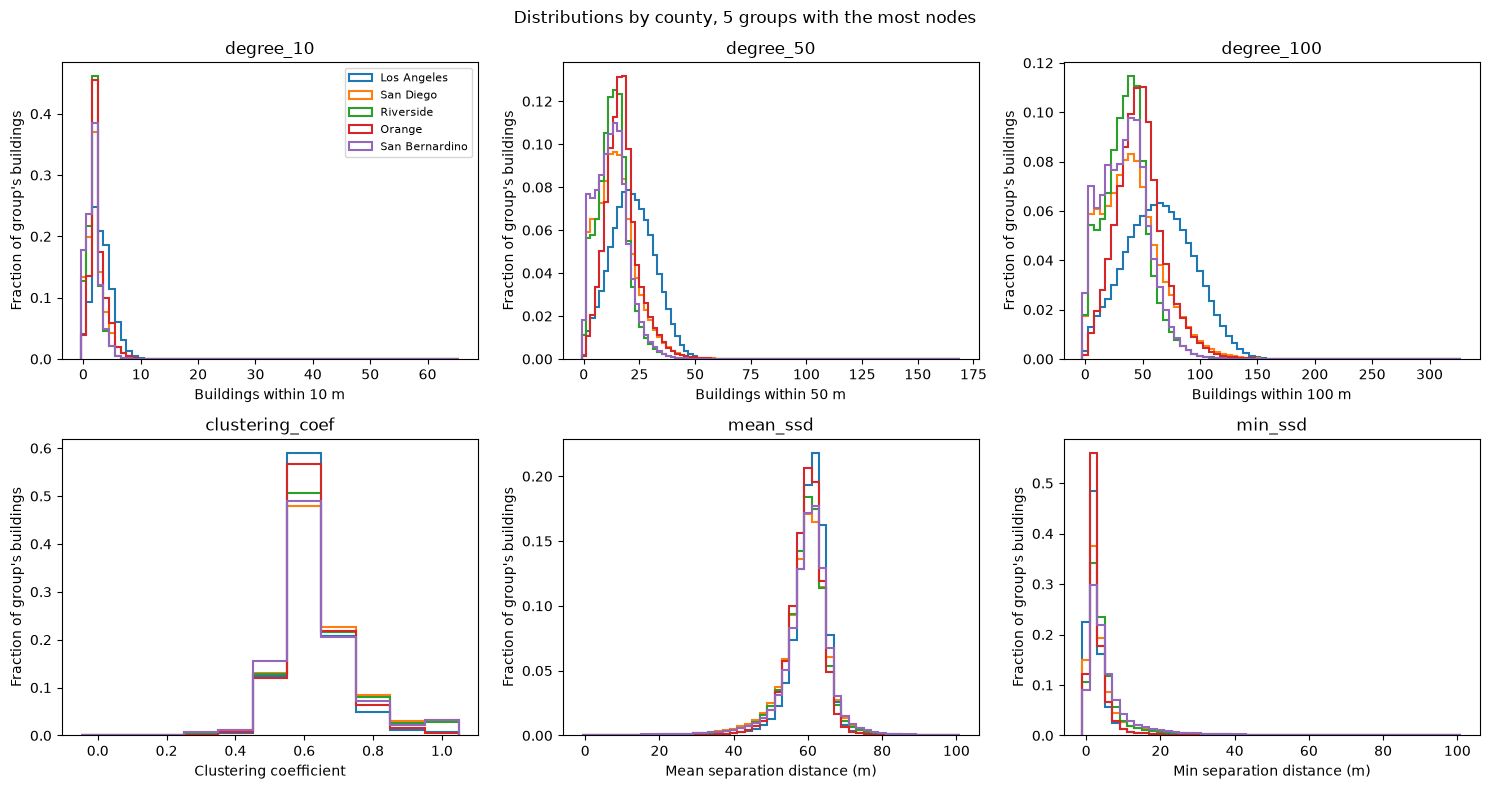

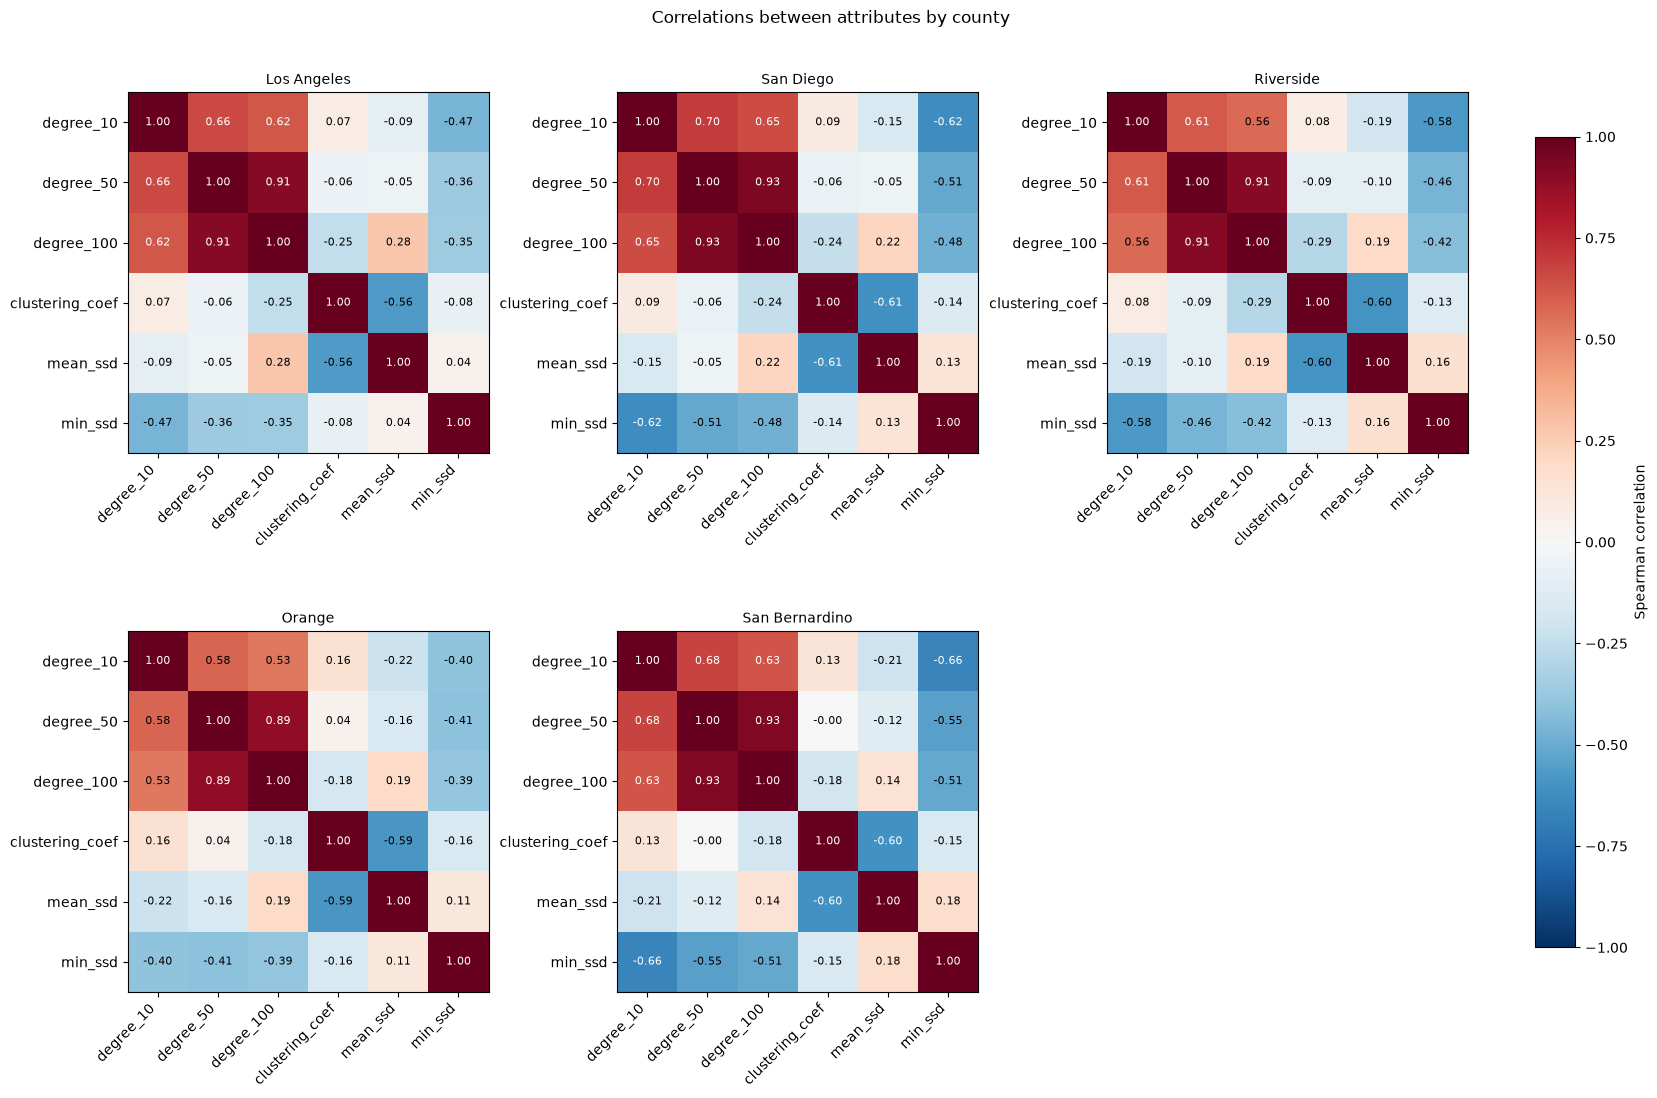

In [12]:
#Assign a county to each node
joined = gpd.sjoin(points, counties, how="left", predicate="within") #Reuses points from ecoregion assignment

joined = joined[~joined.index.duplicated()] #Guard against a point matching two counties (keeps the first match)

nodes["county"] = joined["county"]
nodes["county_fips"] = joined["county_fips"]

print(nodes["county"].isna().sum(), "nodes not in any county")

#Summary stats and histograms by county
county_summary = summarize_nodes(nodes, "county")

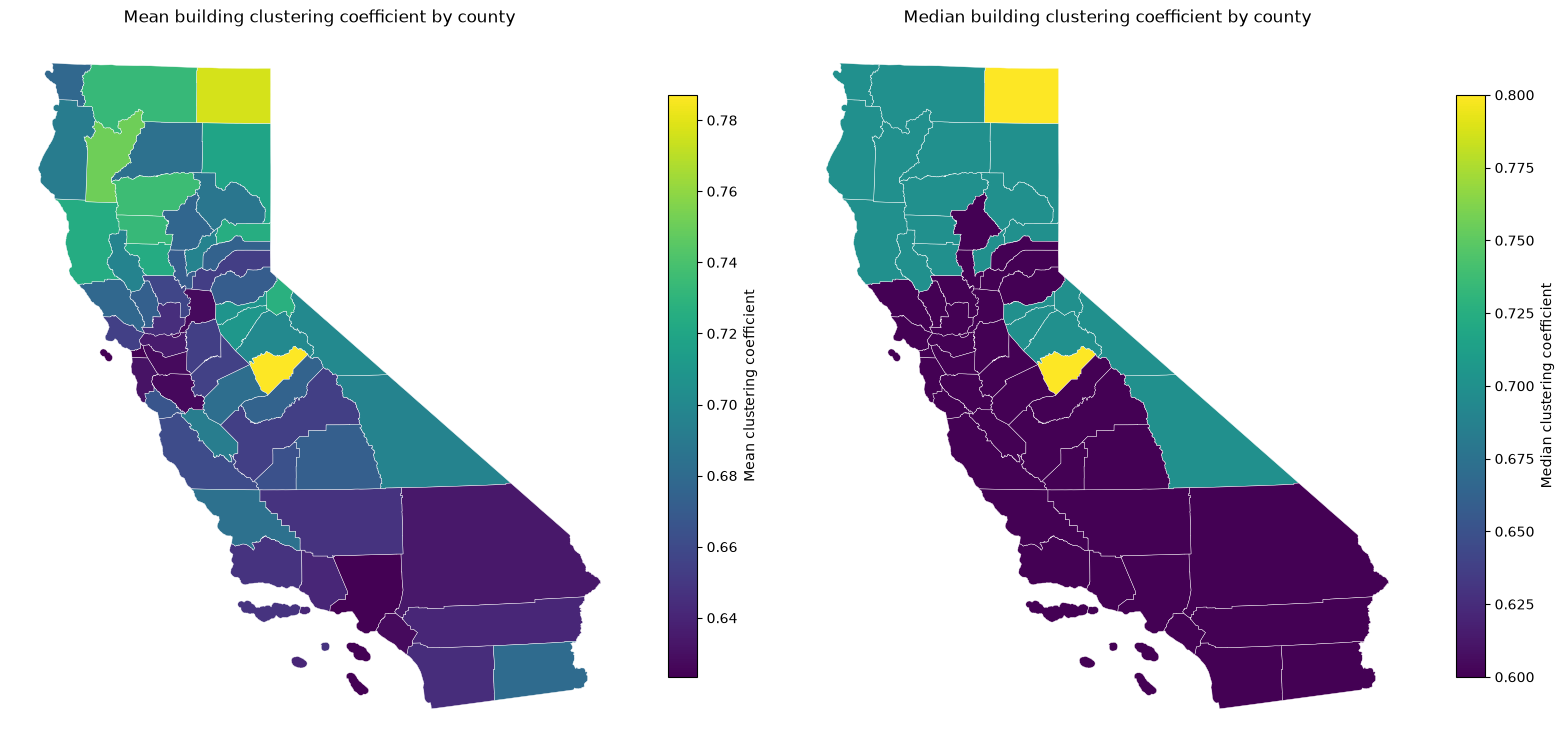

In [7]:
#Choropleth maps of mean and median clustering coefficient per county

#Mean and median skip buildings with no clustering_coef; n_with_coef is how many went into each
county_clustering = (
    nodes.groupby("county_fips")["clustering_coef"]
    .agg(mean_clustering="mean", median_clustering="median", n_with_coef="count")
    .reset_index()
)

counties_clustering = counties.merge(county_clustering, on="county_fips", how="left")


fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, stat in zip(axes, ["mean_clustering", "median_clustering"], ["Mean", "Median"]):
    counties_clustering.plot(
        column=col,
        cmap="viridis",
        legend=True,
        legend_kwds={"label": f"{stat} clustering coefficient", "shrink": 0.6},
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=ax,
    )
    ax.set_title(f"{stat} building clustering coefficient by county")
    ax.set_axis_off()

plt.tight_layout()
plt.show()


Los Angeles as expected has the most buildings. 253 buildings were not assigned a county: I am going to ignore those here as it is a basic exploration, but would further investigate those in a more detailed exploration. San Francisco, however, has the highest building average for the number of other buildings within 10 m of it, followed by Los Angeles. Same for degree_50. The buildings not assigned a county have the highest average clustering_coef. They are probably within a cluster themselves. The county with the highest average clustering_coef is Mariposa, which is a little surprising to me at first. But it follows from how the clustering coefficient is measured on the 100 m network: urban buildings have many neighbors spread far enough apart that many pairs of them are not connected to each other, which lowers clustering, while rural buildings tend to sit in small, tight groups. Los Angeles and San Franscisco have the two lowest average clustering_coef values. San Francisco and Los Angeles have the highest mean mean_ssd and Mariposa is third lowest (Modoc second lowest and missing county lowest). Los Angeles has a relatively normal distribution of degree_50 and degree_100, but most (of the other counties with high numbers of buildings) are more right-skewed. There is a lot more uniform variation in the map of mean county clustering_coef than median county clustering_coef. This makes sense because the median are actual values and they have precisions of 1 decimal place so they can only be 0.6, 0.7, and 0.8 here, whereas the mean can reflect more of the distribution of values within the county. 

In [8]:
#Counties of the nodes removed for having no objectid (check to make sure they are not concentrated)

#Same approach as the county assignment above: one point inside each footprint
no_id_points = gpd.GeoDataFrame(geometry=no_id_nodes.geometry.representative_point(), crs=no_id_nodes.crs)
no_id_joined = gpd.sjoin(no_id_points, counties, how="left", predicate="within")
no_id_joined = no_id_joined[~no_id_joined.index.duplicated()]

no_id_by_county = no_id_joined["county"].value_counts(dropna=False).rename("n_removed").to_frame()
no_id_by_county["percent_of_removed"] = 100 * no_id_by_county["n_removed"] / len(no_id_joined)
no_id_by_county.style.format({"n_removed": "{:,}", "percent_of_removed": "{:.1f}"})

#They are spread across many counties, so it does not seem like they are just a spot that Vibrant Planet had not gotten to calculating values for yet.
#They do make up a larger share of the buildings in rural counties (e.g., ~6.7% in Mendocino vs ~0.1% in Los Angeles), which fits them being buildings with no neighbors within 100 m. 

,n_removed,percent_of_removed
county,,
San Bernardino,"6,334",6.2
Kern,"5,480",5.3
San Diego,"4,959",4.8
Mendocino,"4,491",4.4
Fresno,"4,254",4.2
Riverside,"4,113",4.0
Tulare,"3,692",3.6
Humboldt,"3,197",3.1
San Luis Obispo,"3,186",3.1


## Filter to data where building connectivity likely has an influence

Filter out areas where other influences are likely stronger such as wildlands, areas where there are dense trees. In the future, I would also filter out uphill slopes.  

## Proximity to the Riley et al. (2025) dataset

If Open Climate Risk has focused on spread from wildlands to urban areas, how much of these building data are close to the wildlands? 

### Number of nodes by risk_distance_class

,n_nodes,percent
risk_distance_class,,
0-500 m,"5,249,626",38.81
500 m-1 km,"4,027,178",29.77
In risk area,"2,471,948",18.27
1-2 km,"1,535,497",11.35
2-5 km,"243,416",1.80
> 5 km,7,0.00


### degree_10 by risk_distance_class (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
risk_distance_class,,,,,,,,,
2-5 km,"243,416",0,4.078,4.000,1.911,0.000,3.000,5.000,21.000
1-2 km,"1,535,497",0,3.438,3.000,1.788,0.000,2.000,4.000,43.000
500 m-1 km,"4,027,178",0,2.748,2.000,1.571,0.000,2.000,4.000,65.000
0-500 m,"5,249,626",0,2.033,2.000,1.396,0.000,1.000,3.000,51.000
In risk area,"2,471,948",0,1.220,1.000,1.250,0.000,0.000,2.000,39.000
> 5 km,7,0,0.286,0.000,0.488,0.000,0.000,0.500,1.000


### degree_50 by risk_distance_class (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
risk_distance_class,,,,,,,,,
2-5 km,"243,416",0,27.012,28.000,9.746,0.000,21.000,34.000,74.000
1-2 km,"1,535,497",0,23.228,23.000,9.622,0.000,17.000,30.000,131.000
500 m-1 km,"4,027,178",0,18.984,18.000,8.599,0.000,13.000,24.000,119.000
0-500 m,"5,249,626",0,13.980,13.000,8.041,0.000,8.000,18.000,167.000
In risk area,"2,471,948",0,7.678,6.000,7.045,0.000,2.000,12.000,149.000
> 5 km,7,0,1.143,1.000,0.900,0.000,0.500,2.000,2.000


### clustering_coef by risk_distance_class (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
risk_distance_class,,,,,,,,,
> 5 km,3,4,1.000,1.000,0.000,1.000,1.000,1.000,1.000
In risk area,"2,321,199","150,749",0.706,0.700,0.171,0.100,0.600,0.800,1.000
0-500 m,"5,204,978","44,648",0.641,0.600,0.112,0.000,0.600,0.700,1.000
1-2 km,"1,534,426","1,071",0.620,0.600,0.080,0.100,0.600,0.700,1.000
2-5 km,"243,192",224,0.620,0.600,0.078,0.200,0.600,0.700,1.000
500 m-1 km,"4,022,106","5,072",0.617,0.600,0.081,0.100,0.600,0.600,1.000


### mean_ssd by risk_distance_class (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
risk_distance_class,,,,,,,,,
2-5 km,"243,416",0,60.725,61.357,4.816,0.000,58.686,63.579,99.319
1-2 km,"1,535,497",0,60.550,61.140,4.815,0.000,58.475,63.378,99.964
500 m-1 km,"4,027,178",0,60.342,60.896,4.978,0.000,58.301,63.141,99.963
0-500 m,"5,249,626",0,58.826,59.973,7.671,0.000,56.620,62.686,99.981
In risk area,"2,471,948",0,54.783,57.760,14.185,0.000,50.300,62.401,99.988
> 5 km,7,0,40.846,27.979,41.735,1.445,10.600,68.233,98.834


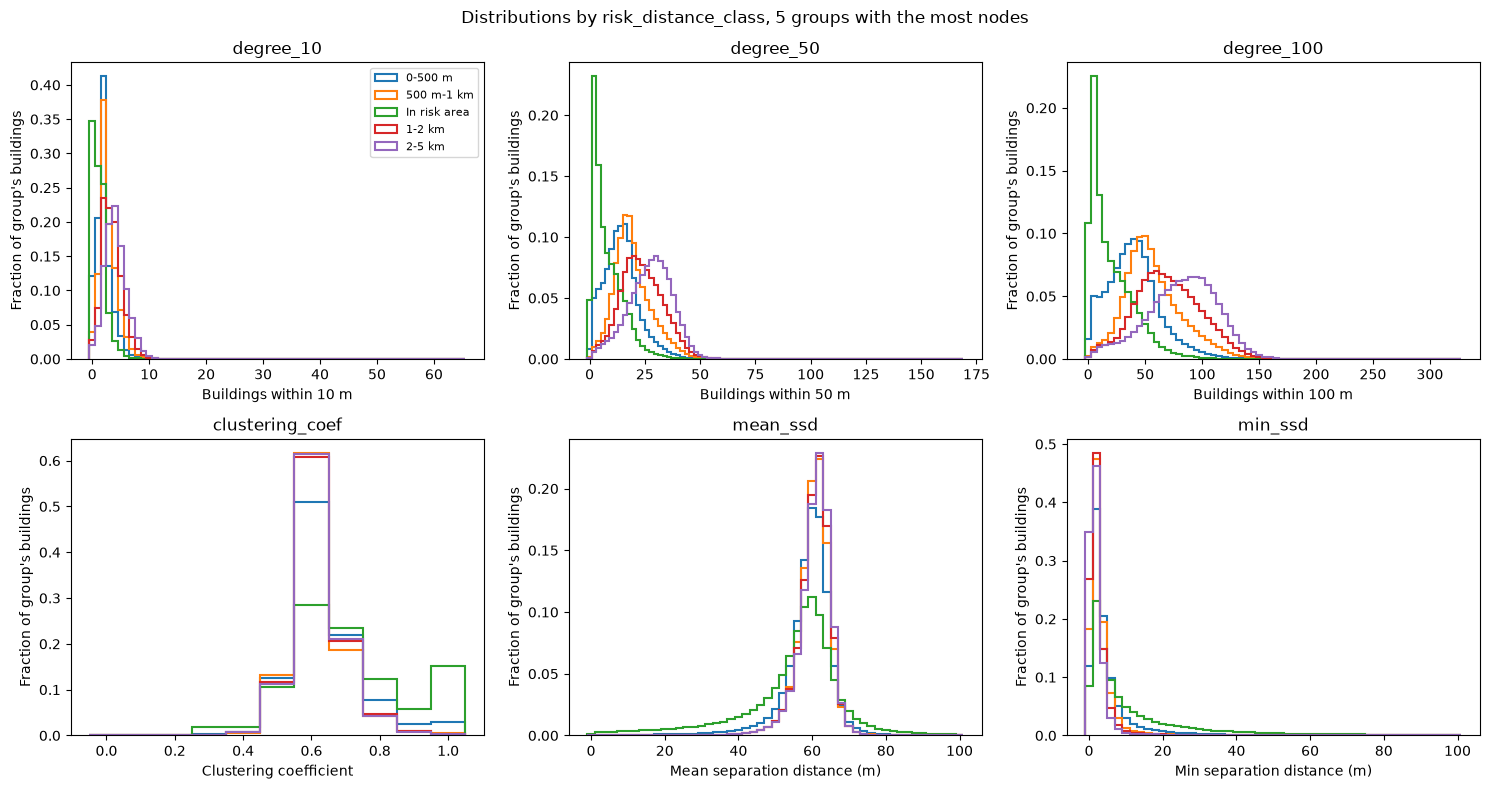

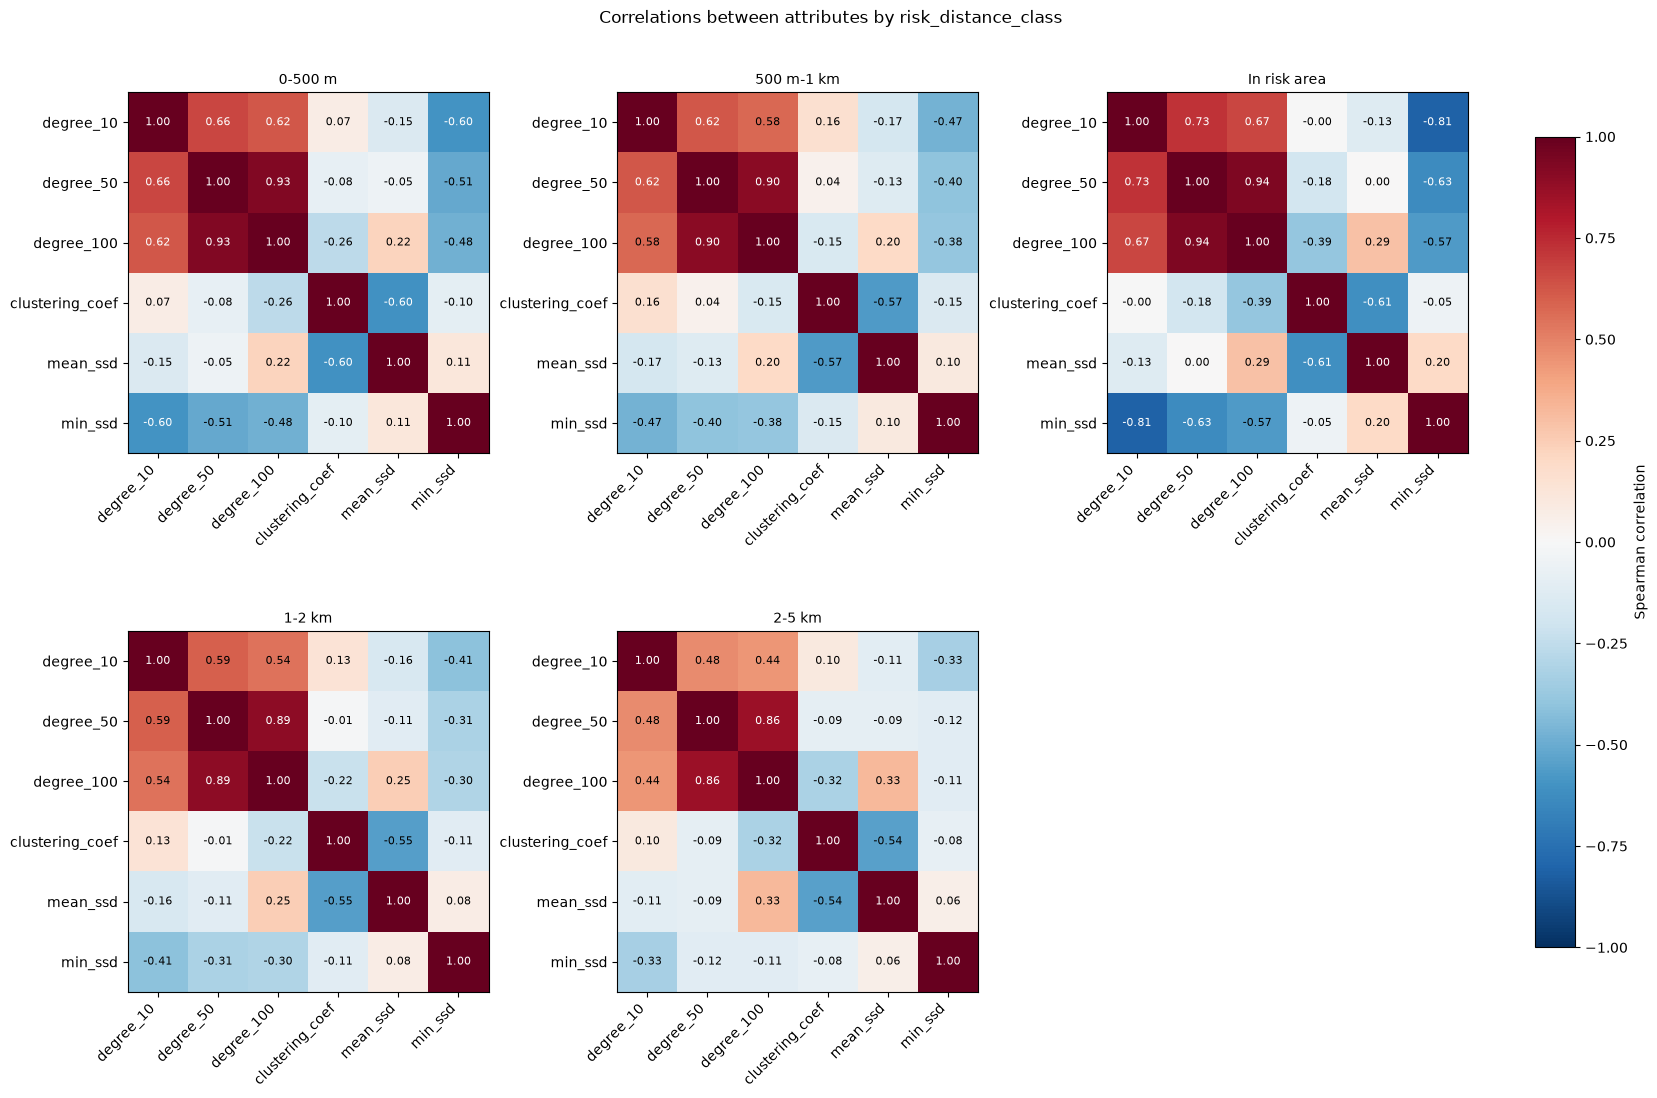

{'counts':                      n_nodes  percent
 risk_distance_class                  
 0-500 m              5249626    38.81
 500 m-1 km           4027178    29.77
 In risk area         2471948    18.27
 1-2 km               1535497    11.35
 2-5 km                243416     1.80
 > 5 km                     7     0.00,
 'degree_10':                        count  missing      mean  median       std  min  25%  \
 risk_distance_class                                                           
 2-5 km                243416        0  4.078195     4.0  1.911457  0.0  3.0   
 1-2 km               1535497        0  3.438080     3.0  1.787662  0.0  2.0   
 500 m-1 km           4027178        0  2.747751     2.0  1.570615  0.0  2.0   
 0-500 m              5249626        0  2.033369     2.0  1.396205  0.0  1.0   
 In risk area         2471948        0  1.219525     1.0  1.249684  0.0  0.0   
 > 5 km                     7        0  0.285714     0.0  0.487950  0.0  0.0   
 
                      

In [14]:
#Riley et al. (2025) FSim annual burn probability (BP), 270 m. BP is 0 where the model treats the
#landscape as unable to burn (urban cores, water, most agriculture) and > 0 in burnable wildland,
#so the "wildfire risk area" here is every pixel with BP > bp_threshold.
climate_run = "2011ClimateRun"  # or "2047ClimateRun" for projected mid-century climate
bp_threshold = 0
riley_zip = Path("Data/RDS-2025-0006.zip")
riley_ca_file = Path(f"Data/riley2025_BP_{climate_run}_CA.tif")

#Extract just the California part of the CONUS raster from the zip once and save it
if not riley_ca_file.exists():
    with rasterio.open(f"/vsizip/{riley_zip}/Data/{climate_run}/BP.tif") as src:
        # California plus a 10 km margin, so buildings near the state line can find risk areas across it
        bounds = counties.to_crs(src.crs).total_bounds + np.array([-10_000, -10_000, 10_000, 10_000])
        window = from_bounds(*bounds, transform=src.transform).round_offsets().round_lengths()
        bp = src.read(1, window=window, boundless=True, fill_value=src.nodata)
        profile = src.profile | {
            "height": bp.shape[0], "width": bp.shape[1],
            "transform": src.window_transform(window), "compress": "deflate",
        }
    with rasterio.open(riley_ca_file, "w", **profile) as dst:
        dst.write(bp, 1)

with rasterio.open(riley_ca_file) as src:
    bp = src.read(1, masked=True)
    riley_transform, riley_crs = src.transform, src.crs

#Distance (m) from every pixel's center to the nearest risk-area pixel's center (0 inside the risk area)
risk_area = (bp > bp_threshold).filled(False)
distance_m = distance_transform_edt(~risk_area) * riley_transform.a

#Look up each building's pixel, using the one-point-per-building layer
pts = points.geometry.to_crs(riley_crs)
cols, rows = ~riley_transform * (pts.x.to_numpy(), pts.y.to_numpy())
rows, cols = np.floor(rows).astype(int), np.floor(cols).astype(int)
nodes["burn_probability"] = bp.filled(np.nan)[rows, cols]
nodes["dist_to_risk_area_m"] = distance_m[rows, cols]

#Group into distance bands. Pixels are 270 m, so the closest possible nonzero distance is 270 m
#and distances are only meaningful to within a few hundred meters.
nodes["risk_distance_class"] = pd.cut(
    nodes["dist_to_risk_area_m"],
    bins=[-np.inf, 0, 500, 1000, 2000, 5000, np.inf],
    labels=["In risk area", "0-500 m", "500 m-1 km", "1-2 km", "2-5 km", "> 5 km"],
)

risk_counts = nodes["risk_distance_class"].value_counts(sort=False).rename("n_nodes").to_frame()
risk_counts["percent"] = 100 * risk_counts["n_nodes"] / len(nodes)
risk_counts.style.format({"n_nodes": "{:,}", "percent": "{:.1f}"})

summarize_nodes(nodes, "risk_distance_class")

Almost all of the buildings are within 5 km of the risk area. The majority are within 500 m of the wildland risk area. 
Only 18% is in the risk area for wildland burning so burning of the rest of the buildings would likely be more impacted by connectivity.
Going to filter out the in risk area buildings to decrease the dataset some. 

In [15]:
nodes_filtered = nodes[nodes['risk_distance_class'] != "In risk area"]
print(nodes_filtered['risk_distance_class'].unique()) #Check to make sure in risk area was removed

['0-500 m', '500 m-1 km', '1-2 km', '2-5 km', '> 5 km']
Categories (6, str): ['In risk area' < '0-500 m' < '500 m-1 km' < '1-2 km' < '2-5 km' < '> 5 km']


In [20]:
#Assign mean tree canopy cover around each filtered node

#Mean percent tree canopy cover (NLCD TCC from the USFS) within radius_m of each building in nodes_filtered.
#Reading the raster over the internet is slow, so the result is saved in Data/ the first time
#and read back from there afterwards
#Only assigning canopy cover for the filtered nodes decreases the storage but does not substantially improve download speed
canopy_file = Path(f"{DATA_DIR}nodes_filtered_tree_canopy_{veg_year}_{radius_m}m.parquet")

if canopy_file.exists():
    canopy = pd.read_parquet(canopy_file)
else:
    #Points for just the filtered nodes (points shares row labels with nodes, which nodes_filtered kept).
    #Skip GDAL's listing of the remote folder, which is slow and not needed
    filtered_points = points.loc[nodes_filtered.index]
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
        canopy = mean_tree_canopy(tcc_url, filtered_points.geometry, radius_m).to_frame()
    canopy.insert(0, "objectid", nodes_filtered["objectid"].to_numpy())
    canopy = canopy.reset_index(drop=True)
    canopy.to_parquet(canopy_file)

#The saved rows are in the same order as nodes_filtered; check before copying the column over.
#If the filter changes, delete the saved file so it's recalculated for the new set of nodes
assert len(canopy) == len(nodes_filtered) and (canopy["objectid"].to_numpy() == nodes_filtered["objectid"].to_numpy()).all(), \
    f"saved tree canopy rows don't match nodes_filtered; delete {canopy_file} to recalculate"
nodes_filtered["tree_canopy_pct"] = canopy["tree_canopy_pct"].to_numpy()

print(f"{nodes_filtered['tree_canopy_pct'].isna().sum():,} filtered nodes with no tree canopy value")
nodes_filtered["tree_canopy_pct"].describe().round(1)

0 filtered nodes with no tree canopy value


count    11055724.0
mean            7.2
std             7.2
min             0.0
25%             1.7
50%             5.6
75%            10.4
max            81.8
Name: tree_canopy_pct, dtype: float64

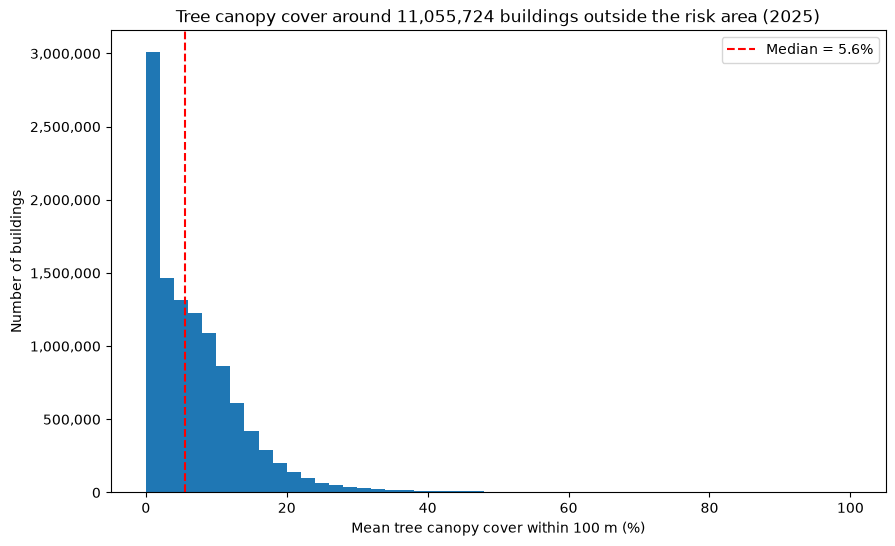

(8108038, 16)
Removed 2,947,686 of 11,055,724 buildings (26.7%) with 10% or more tree cover


In [26]:
#Histogram of mean percent tree canopy cover around each filtered node

canopy_values = nodes_filtered["tree_canopy_pct"].dropna()
canopy_median = canopy_values.median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(canopy_values, bins=np.arange(0, 102, 2)) #2% wide bins from 0 to 100%
ax.axvline(canopy_median, color="red", linestyle="--", label=f"Median = {canopy_median:.1f}%")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}")) #Counts with commas instead of 1e6
ax.set_xlabel(f"Mean tree canopy cover within {radius_m} m (%)")
ax.set_ylabel("Number of buildings")
ax.set_title(f"Tree canopy cover around {len(canopy_values):,} buildings outside the risk area ({veg_year})")
ax.legend()
plt.show()

#It makes sense that the canopy dover percentage distribution is skewed right because these should be relatively urban areas (outside of the Riley et al. 2025)

#Going to only keep buildings in areas with less than 10% tree cover. This number is somewhat arbitrary and in a proper analysis I would dig deeper into it
#Tree cover also does not account for chaparral, shrubs, and grasses which could help spread fire too. 
#Tree cover is just one product to remove some of the buildings that are surrounded by trees so I can look at others

nodes_filtered2 = nodes_filtered[(nodes_filtered["tree_canopy_pct"] < 10) & (nodes_filtered["tree_canopy_pct"].notna())]
print(nodes_filtered2.shape)
n_removed = len(nodes_filtered) - len(nodes_filtered2)
print(f"Removed {n_removed:,} of {len(nodes_filtered):,} buildings ({100 * n_removed / len(nodes_filtered):.1f}%) with 10% or more tree cover")


## Look at differences between counties again but on nodes_filtered2

### Number of nodes by county

,n_nodes,percent
county,,
Los Angeles,"2,260,083",27.87
Riverside,"641,423",7.91
San Diego,"608,023",7.50
Orange,"525,878",6.49
San Bernardino,"510,315",6.29
Alameda,"324,886",4.01
Santa Clara,"316,775",3.91
Kern,"288,947",3.56
Fresno,"258,853",3.19


### degree_10 by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"142,551",0,3.918,4.000,1.447,0.000,3.000,4.000,39.000
nan,182,0,3.560,2.000,4.009,0.000,1.000,5.000,16.000
Los Angeles,"2,260,083",0,3.539,3.000,1.808,0.000,2.000,5.000,50.000
Alameda,"324,886",0,3.199,3.000,1.860,0.000,2.000,4.000,30.000
Santa Clara,"316,775",0,2.983,3.000,1.750,0.000,2.000,4.000,51.000
San Mateo,"106,645",0,2.838,2.000,1.574,0.000,2.000,4.000,22.000
Santa Cruz,"43,147",0,2.835,3.000,1.596,0.000,2.000,4.000,15.000
Orange,"525,878",0,2.684,2.000,1.485,0.000,2.000,3.000,35.000
Monterey,"92,967",0,2.663,2.000,1.620,0.000,2.000,4.000,23.000


### degree_50 by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"142,551",0,32.714,34.000,9.180,0.000,28.000,39.000,87.000
Los Angeles,"2,260,083",0,23.203,23.000,9.469,0.000,17.000,30.000,100.000
Alameda,"324,886",0,22.819,21.000,10.674,0.000,15.000,30.000,84.000
San Mateo,"106,645",0,21.921,21.000,9.625,0.000,16.000,27.000,80.000
Santa Cruz,"43,147",0,20.338,20.000,9.053,0.000,14.000,26.000,64.000
Santa Clara,"316,775",0,19.435,18.000,9.640,0.000,14.000,24.000,107.000
Contra Costa,"185,253",0,17.958,16.000,9.840,0.000,12.000,22.000,119.000
Orange,"525,878",0,17.847,17.000,7.713,0.000,13.000,21.000,88.000
Monterey,"92,967",0,17.497,17.000,8.642,0.000,12.000,23.000,69.000


### clustering_coef by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
nan,167,15,0.864,0.900,0.131,0.400,0.800,1.000,1.000
Alpine,115,15,0.752,0.700,0.177,0.300,0.600,0.950,1.000
Mariposa,"1,505",121,0.726,0.700,0.183,0.200,0.600,0.900,1.000
Mono,"1,860",81,0.718,0.700,0.163,0.300,0.600,0.800,1.000
Modoc,"3,685",380,0.710,0.700,0.174,0.300,0.600,0.800,1.000
Siskiyou,"9,312",601,0.703,0.700,0.169,0.100,0.600,0.800,1.000
Tuolumne,"2,842",85,0.698,0.700,0.161,0.200,0.600,0.800,1.000
Nevada,"2,334",64,0.693,0.700,0.153,0.200,0.600,0.800,1.000
Mendocino,"11,255",302,0.689,0.700,0.148,0.200,0.600,0.800,1.000


### mean_ssd by county (sorted by mean)

,count,missing,mean,median,std,min,25%,75%,max
county,,,,,,,,,
San Francisco,"142,551",0,60.503,61.187,4.027,0.234,58.924,62.873,99.652
Los Angeles,"2,260,083",0,60.460,61.059,4.960,0.000,58.363,63.345,99.822
Alameda,"324,886",0,60.245,60.886,5.244,0.000,58.169,63.203,99.964
Santa Clara,"316,775",0,59.912,60.719,5.924,0.000,57.717,63.234,99.663
San Mateo,"106,645",0,59.696,60.432,5.406,0.000,57.722,62.664,99.471
San Bernardino,"510,315",0,59.598,60.480,7.208,0.000,57.270,63.149,99.981
Orange,"525,878",0,59.545,60.141,4.954,0.000,57.377,62.426,99.948
Kern,"288,947",0,59.455,60.509,7.273,0.000,57.388,63.088,99.844
Contra Costa,"185,253",0,59.419,60.206,6.104,0.000,57.185,62.761,99.788


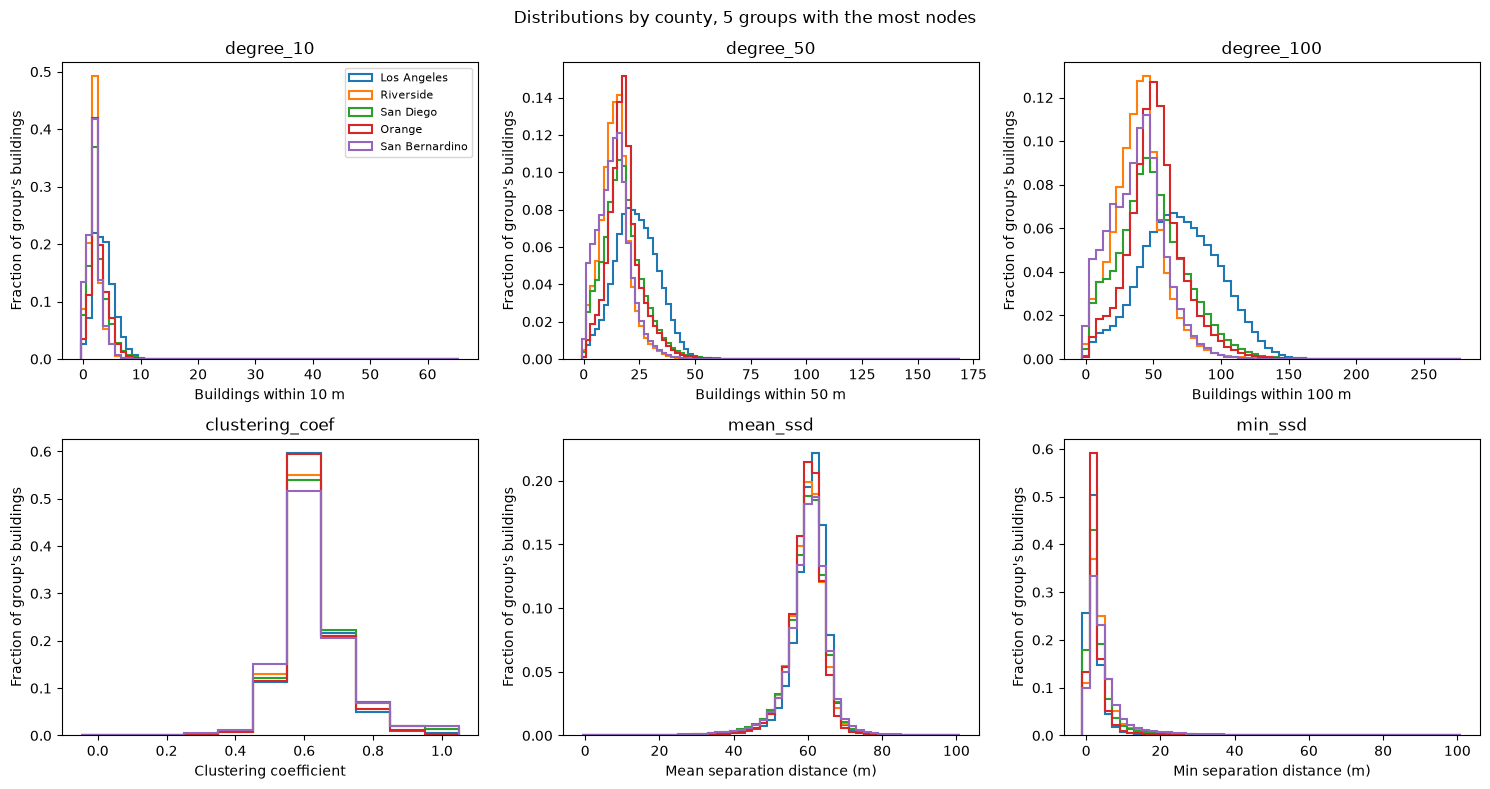

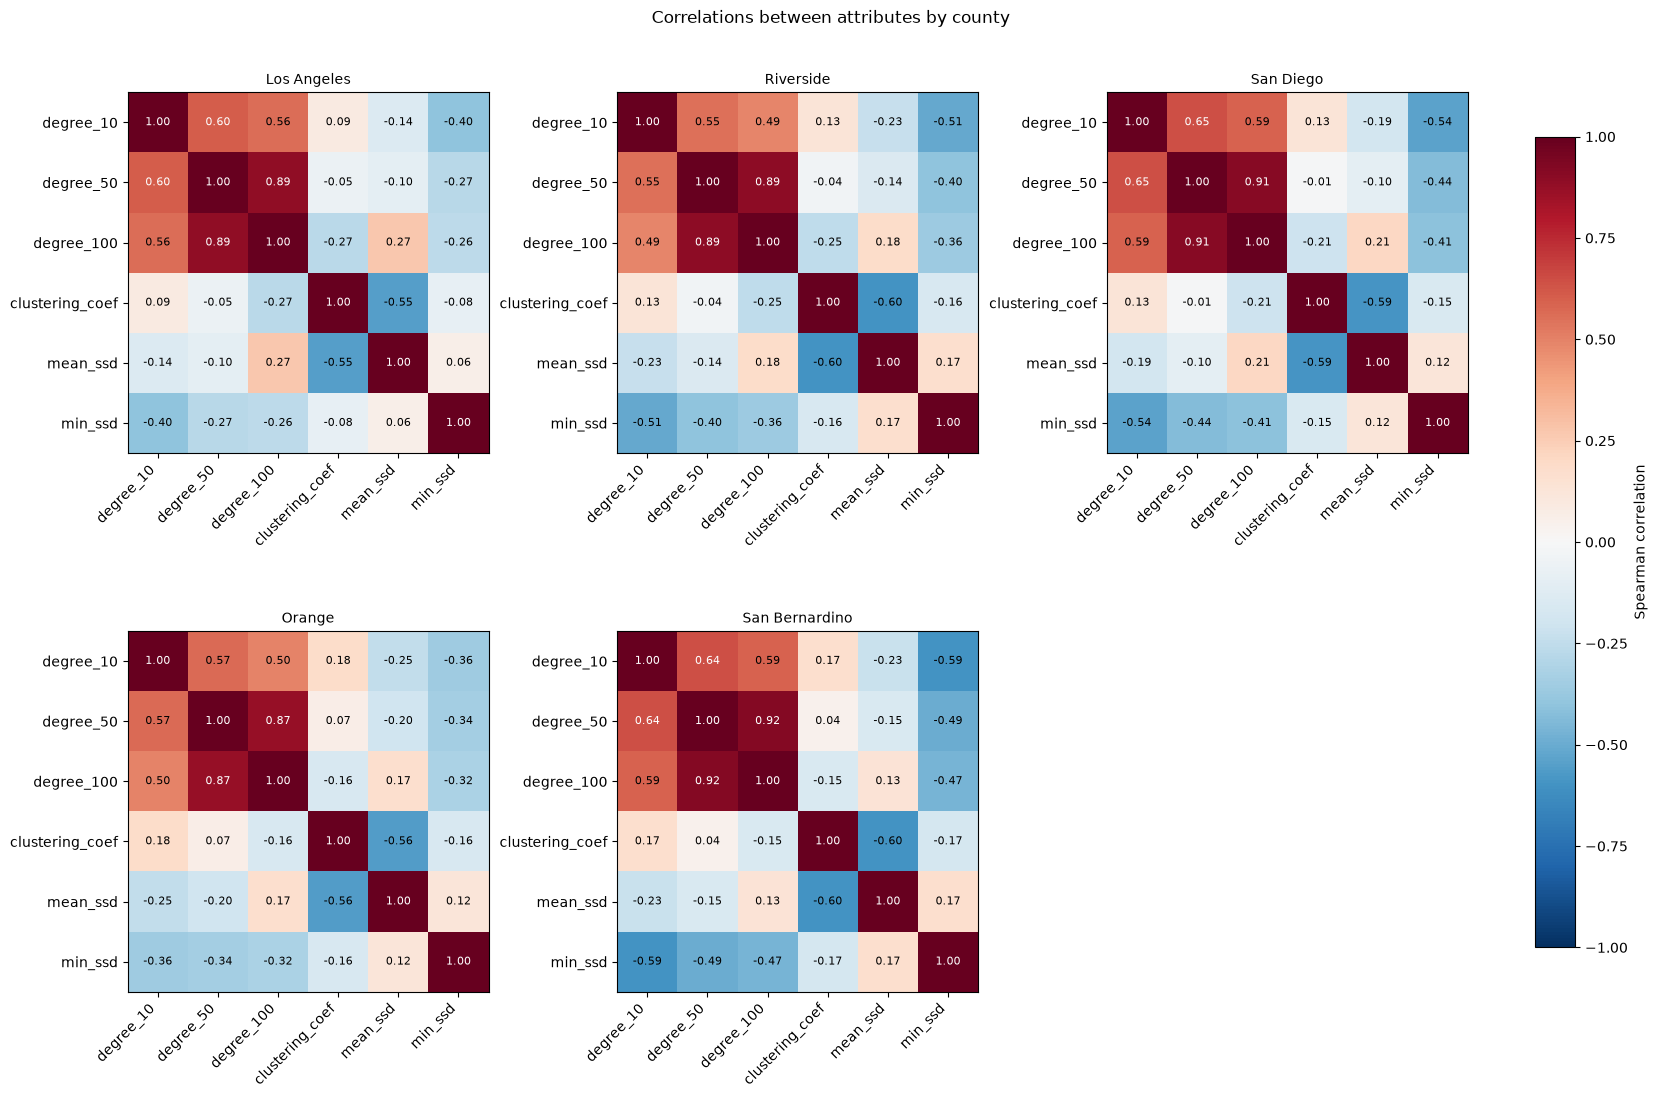

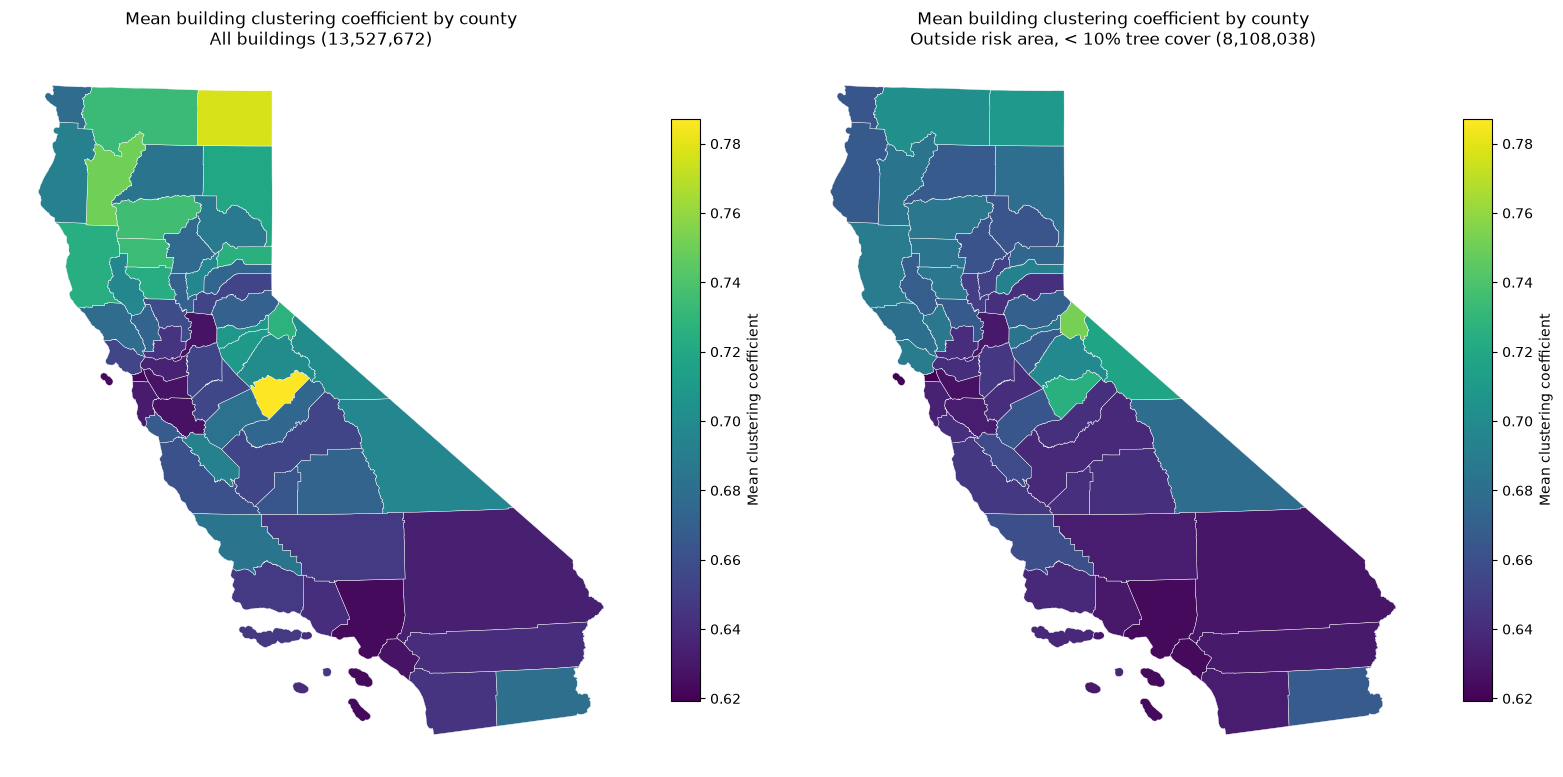

In [27]:
#Summary stats and histograms by county for nodes_filtered2 (outside the risk area, less than 10% tree cover)
county_summary_filtered2 = summarize_nodes(nodes_filtered2, "county")

#Mean and median clustering coefficient per county for nodes_filtered2 (same as county_clustering above)
county_clustering_filtered2 = (
    nodes_filtered2.groupby("county_fips")["clustering_coef"]
    .agg(mean_clustering="mean", median_clustering="median", n_with_coef="count")
    .reset_index()
)

counties_clustering_filtered2 = counties.merge(county_clustering_filtered2, on="county_fips", how="left")

#Choropleth maps of mean clustering coefficient per county: all nodes (left) vs nodes_filtered2 (right)
#Same color scale on both panels so the same color means the same value
vmin = min(counties_clustering["mean_clustering"].min(), counties_clustering_filtered2["mean_clustering"].min())
vmax = max(counties_clustering["mean_clustering"].max(), counties_clustering_filtered2["mean_clustering"].max())

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

panels = [
    (counties_clustering, f"All buildings ({len(nodes):,})"),
    (counties_clustering_filtered2, f"Outside risk area, < 10% tree cover ({len(nodes_filtered2):,})"),
]
for ax, (data, title) in zip(axes, panels):
    data.plot(
        column="mean_clustering",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        legend=True,
        legend_kwds={"label": "Mean clustering coefficient", "shrink": 0.6},
        edgecolor="white",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=ax,
    )
    ax.set_title(f"Mean building clustering coefficient by county\n{title}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Social justice. How do structural characteristics compare to places predominately non-white, lower income, etc. 

In [28]:
#Read in ACS county median family income and racial/ethnic minority percentage

#American Community Survey (ACS) 5-year estimates, 2020-2024, from the Census Bureau's table-based summary files
#(pipe-delimited, all geographies in the US; no API key needed). Downloads once (~18 MB + ~83 MB) and saves a
#California-only copy in Data/ for next time
acs_year = 2024
acs_file = Path(f"{DATA_DIR}ca_county_acs_{acs_year}.csv")
acs_base_url = f"https://www2.census.gov/programs-surveys/acs/summary_file/{acs_year}/table-based-SF/data/5YRData/acsdt5y{acs_year}"

if acs_file.exists():
    acs = pd.read_csv(acs_file, dtype={"county_fips": str})
else:
    #B19113: median family income in the past 12 months (inflation-adjusted dollars)
    income = pd.read_csv(f"{acs_base_url}-b19113.dat", sep="|", usecols=["GEO_ID", "B19113_E001", "B19113_M001"], dtype={"GEO_ID": str})
    #B03002: Hispanic or Latino origin by race. E001 = total population, E003 = not Hispanic, white alone
    race = pd.read_csv(f"{acs_base_url}-b03002.dat", sep="|", usecols=["GEO_ID", "B03002_E001", "B03002_E003"], dtype={"GEO_ID": str})

    acs = income.merge(race, on="GEO_ID")
    acs = acs[acs["GEO_ID"].str.startswith("0500000US06")].copy() #California counties (state FIPS 06)
    acs["county_fips"] = acs["GEO_ID"].str[-5:] #Matches county_fips in counties, e.g. 06001

    #ACS uses large negative numbers as codes for unavailable estimates; treat them as missing
    raw_cols = ["B19113_E001", "B19113_M001", "B03002_E001", "B03002_E003"]
    acs[raw_cols] = acs[raw_cols].where(acs[raw_cols] >= 0)

    acs["median_family_income"] = acs["B19113_E001"]
    acs["median_family_income_moe"] = acs["B19113_M001"] #Margin of error (90%)
    #Minority = everyone except non-Hispanic white residents (the standard definition)
    acs["minority_pct"] = 100 * (1 - acs["B03002_E003"] / acs["B03002_E001"])
    acs = acs[["county_fips", "median_family_income", "median_family_income_moe", "minority_pct"]]
    acs.to_csv(acs_file, index=False)

print(len(acs), "counties")
acs.describe().round(1)

58 counties


,median_family_income,median_family_income_moe,minority_pct
count,58.0,58.0,58.0
mean,106813.0,4953.5,50.3
std,30689.7,3965.1,19.8
min,65458.0,573.0,14.0
25%,84964.5,2252.8,34.9
50%,97128.5,3940.5,52.0
75%,122329.0,6478.5,69.8
max,199115.0,20118.0,90.9


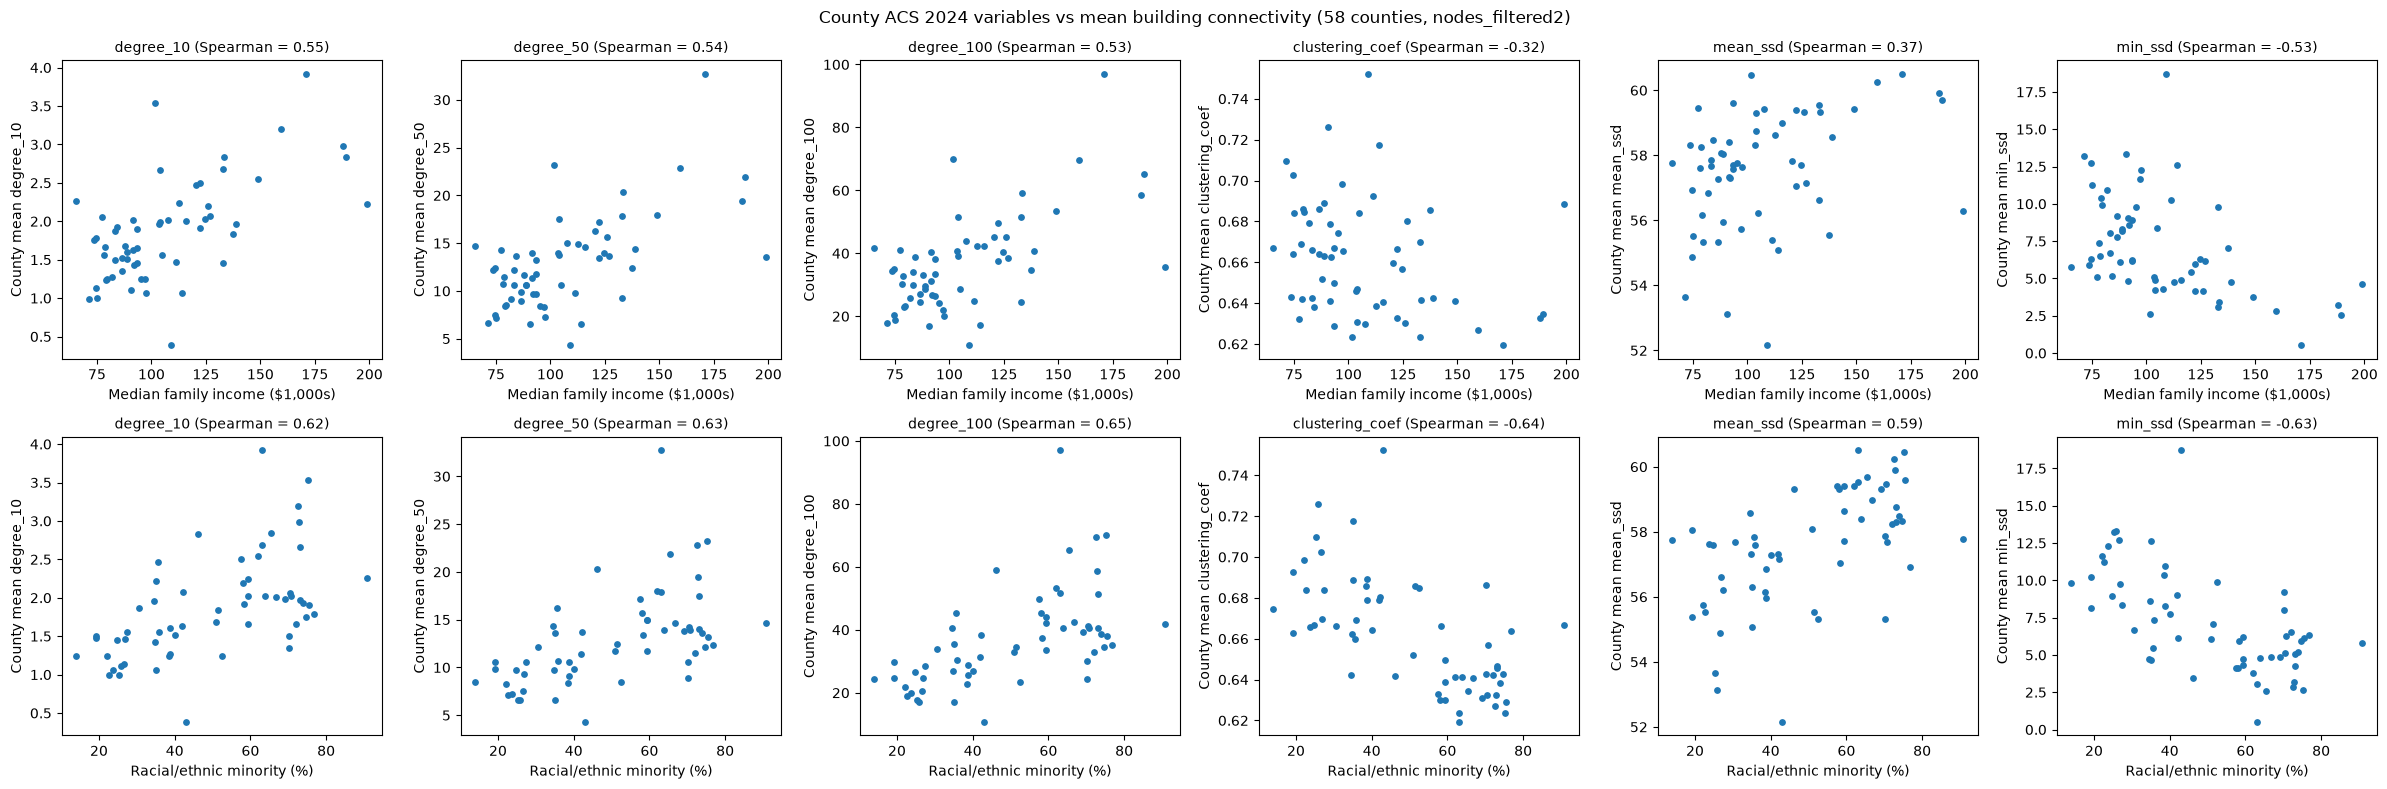

In [29]:
#Correlations between county median family income / minority percentage and building connectivity (nodes_filtered2)

connectivity_cols = list(HIST_SETTINGS) #The attributes plotted in the summarize_nodes histograms
#ACS variable: (x-axis label, scale for plotting). Income is plotted in thousands so the tick labels fit
acs_cols = {
    "median_family_income": ("Median family income ($1,000s)", 1 / 1000),
    "minority_pct": ("Racial/ethnic minority (%)", 1),
}

#Mean of each connectivity attribute per county, for buildings outside the risk area with < 10% tree cover
county_connectivity = nodes_filtered2.groupby("county_fips")[connectivity_cols].mean()
county_connectivity["n_buildings"] = nodes_filtered2.groupby("county_fips").size()
county_acs = (
    counties[["county_fips", "county"]]
    .merge(county_connectivity.reset_index(), on="county_fips")
    .merge(acs, on="county_fips")
)

#Spearman (rank) correlation across counties, one per ACS variable and connectivity attribute
rows = []
for acs_col in acs_cols:
    for col in connectivity_cols:
        valid = county_acs[[acs_col, col]].dropna()
        rho, p = spearmanr(valid[acs_col], valid[col])
        rows.append({"acs_variable": acs_col, "attribute": col, "spearman": rho, "p_value": p, "n_counties": len(valid)})
acs_correlations = pd.DataFrame(rows).set_index(["acs_variable", "attribute"])

#Scatter plots: one row per ACS variable, one column per connectivity attribute
fig, axes = plt.subplots(len(acs_cols), len(connectivity_cols), figsize=(4 * len(connectivity_cols), 4 * len(acs_cols)))
for row_axes, (acs_col, (acs_label, scale)) in zip(axes, acs_cols.items()):
    for ax, col in zip(row_axes, connectivity_cols):
        ax.scatter(county_acs[acs_col] * scale, county_acs[col], s=15)
        rho = acs_correlations.loc[(acs_col, col), "spearman"]
        ax.set_title(f"{col} (Spearman = {rho:.2f})", fontsize=10)
        ax.set_xlabel(acs_label)
        ax.set_ylabel(f"County mean {col}")
fig.suptitle(f"County ACS {acs_year} variables vs mean building connectivity ({len(county_acs)} counties, nodes_filtered2)")
plt.tight_layout()
plt.show()

acs_correlations.style.format({"spearman": "{:.2f}", "p_value": "{:.3f}"})

#There appears to be significant correlations between median family income and the degree_* attributes at the county level.
#This is probably because cities are expensive to live in
#There is also some sort of positive correlation between degree_* and racial minority percent.
#This is also probably because racial minorities might be more likely to live in cities.
#If I really wanted to look at socioeconomic differences between connectivity of structures, I'd need to do it at a finer scale and
#control for more variables like city vs non-city. 

## How to connectivities compare to the current estimated risk in Open Climate Risk?


In [31]:
#Read in the Mariposa County building risk points
mariposa_risk = gpd.read_file(f"{DATA_DIR}Mariposa-County-06043.geojson")

print(len(mariposa_risk), "rows;", mariposa_risk.crs)
mariposa_risk.head()

21093 rows; EPSG:4326


,GEOID,rps_2011,rps_2047,bp_2011,bp_2047,crps_scott,bp_2011_riley,bp_2047_riley,geometry
0,060430001022009,0.158091,0.177534,0.005308,0.005960,29.785353,0.00000,0.00000,POINT (-120.07143 37.45685)
1,060430001022009,0.131801,0.147772,0.005272,0.005911,25.000000,0.00495,0.00505,POINT (-120.07124 37.45721)
2,060430001022009,0.211234,0.221535,0.006051,0.006346,34.910060,0.00620,0.00640,POINT (-120.07122 37.46103)
3,060430001022009,0.211234,0.221535,0.006051,0.006346,34.910060,0.00620,0.00640,POINT (-120.07116 37.46104)
4,060430001022009,0.156141,0.175938,0.005238,0.005902,29.807854,0.00495,0.00505,POINT (-120.07105 37.45745)


Mariposa: 1,626 buildings; 1,615 matched to a risk point (1,621 of 21,093 risk points used)


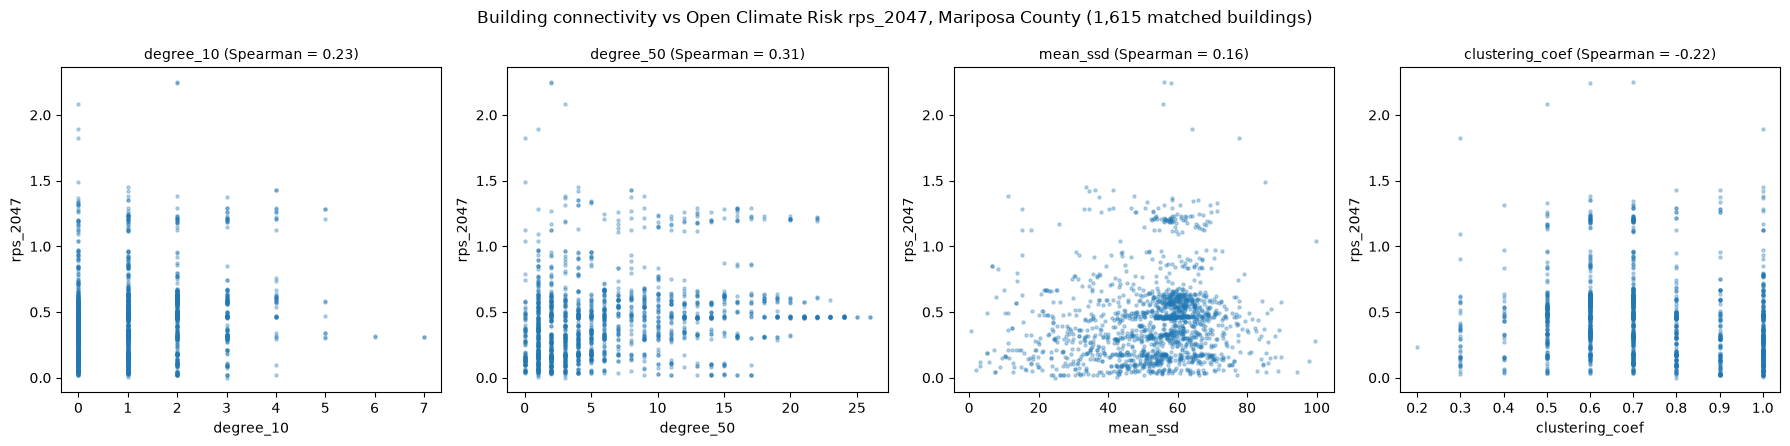

,spearman,p_value,n_buildings
attribute,,,
degree_10,0.23,1.01e-20,"1,615"
degree_50,0.31,9.41e-37,"1,615"
mean_ssd,0.16,6.36e-11,"1,615"
clustering_coef,-0.22,5.06e-18,"1,494"


In [36]:
#Correlations between building connectivity (nodes_filtered2) and Open Climate Risk rps_2047 in Mariposa County
#(correlate_connectivity_with_risk is in risk_correlations.py)
mariposa_matched, mariposa_rps_correlations = correlate_connectivity_with_risk(nodes_filtered2, "Mariposa", f"{DATA_DIR}Mariposa-County-06043.geojson")

Shasta: 29,212 buildings; 29,017 matched to a risk point (29,150 of 106,433 risk points used)


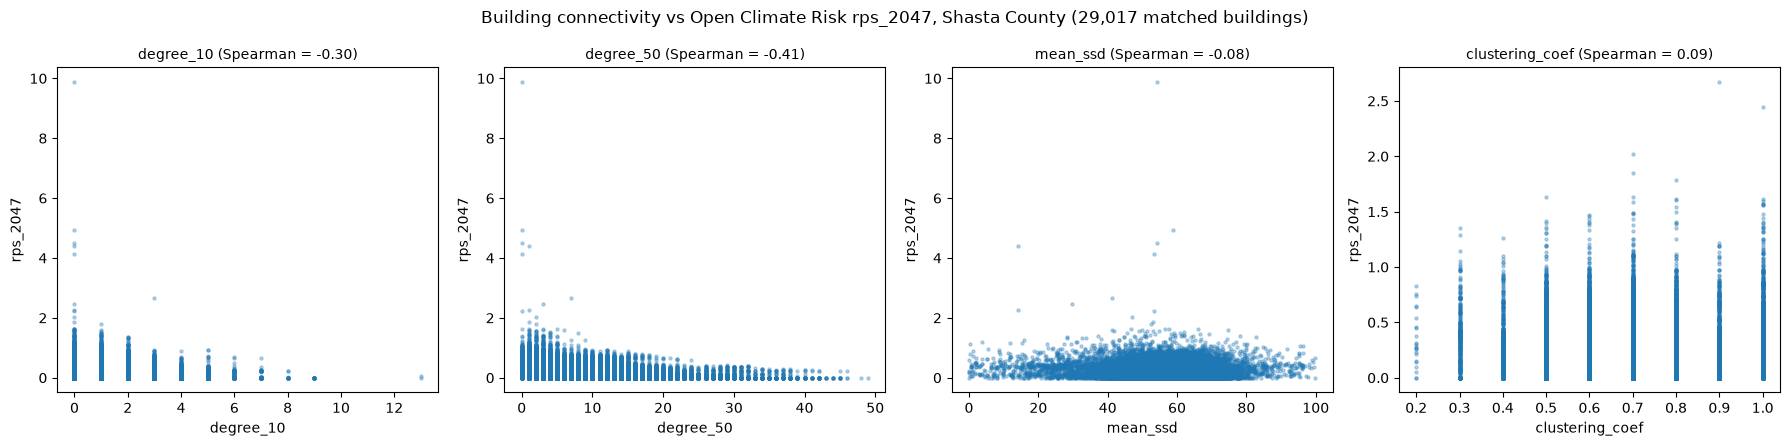

,spearman,p_value,n_buildings
attribute,,,
degree_10,-0.30,0,"29,017"
degree_50,-0.41,0,"29,017"
mean_ssd,-0.08,5.35e-43,"29,017"
clustering_coef,0.09,4.01e-51,"28,467"


In [37]:
#Correlations between building connectivity (nodes_filtered2) and Open Climate Risk rps_2047 in Shasta County
shasta_matched, shasta_rps_correlations = correlate_connectivity_with_risk(nodes_filtered2, "Shasta", f"{DATA_DIR}Shasta-County-06089.geojson")

Sacramento: 250,058 buildings; 248,223 matched to a risk point (249,779 of 527,386 risk points used)


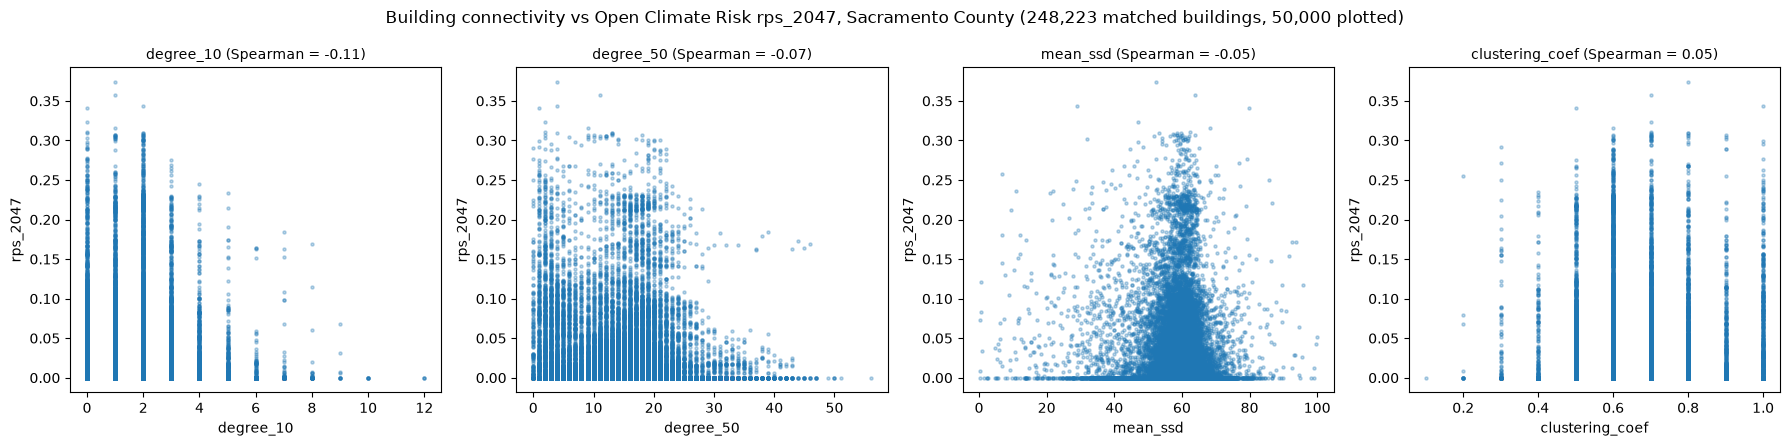

,spearman,p_value,n_buildings
attribute,,,
degree_10,-0.11,0,"248,223"
degree_50,-0.07,1.71e-302,"248,223"
mean_ssd,-0.05,2.93e-118,"248,223"
clustering_coef,0.05,1.17e-113,"247,494"


In [38]:
#Correlations between building connectivity (nodes_filtered2) and Open Climate Risk rps_2047 in Sacramento County
sacramento_matched, sacramento_rps_correlations = correlate_connectivity_with_risk(nodes_filtered2, "Sacramento", f"{DATA_DIR}Sacramento-County-06067.geojson")

No high correlations between the Open Climate Risk 2047 risks in the counties of Sacramento, Shasta, or Mariposa. Sacramento especially has very low correlations and the signs of correlations differ between Shasta and Mariposa. So figuring out the impacts of structural connectivity could add explainatory power of fire risk.

## Some interesting places to make maps of connections between buildings 

In [40]:
#Read in the edges between buildings 0-10 m apart (~15 million rows)

#wkt_edge (the line between the two buildings' centers, only needed for drawing edges on a map) is left out
#because it more than doubles the memory (~2.8 GB vs ~1.3 GB). Add "wkt_edge" to columns to read it too
edges_0_10 = pd.read_parquet(f"{DATA_DIR}ca_vpdc_edges_0_10.parquet", columns=["objectid1", "objectid2", "distance"])

print(f"{len(edges_0_10):,} edges")
edges_0_10.head()

15,144,968 edges


,objectid1,objectid2,distance
0,08b29a0b3640dfff02003a1acc136b6c,08b29a0b3640dfff0200aa94c71baf8a,7.826732
1,08b298d522082fff0200fe9b0a929da2,08b298d522083fff020040e351c2c884,4.519169
2,08b28362264e6fff020067f70d5a64ad,08b28362264f5fff020069b21c2bd724,3.256331
3,08b283472ad0bfff0200209bd8a0495e,08b283472ad0bfff020082de26b56b78,2.542017
4,08b2832100a58fff0200223db5036a55,08b2832100a58fff0200607960105ec6,6.531565


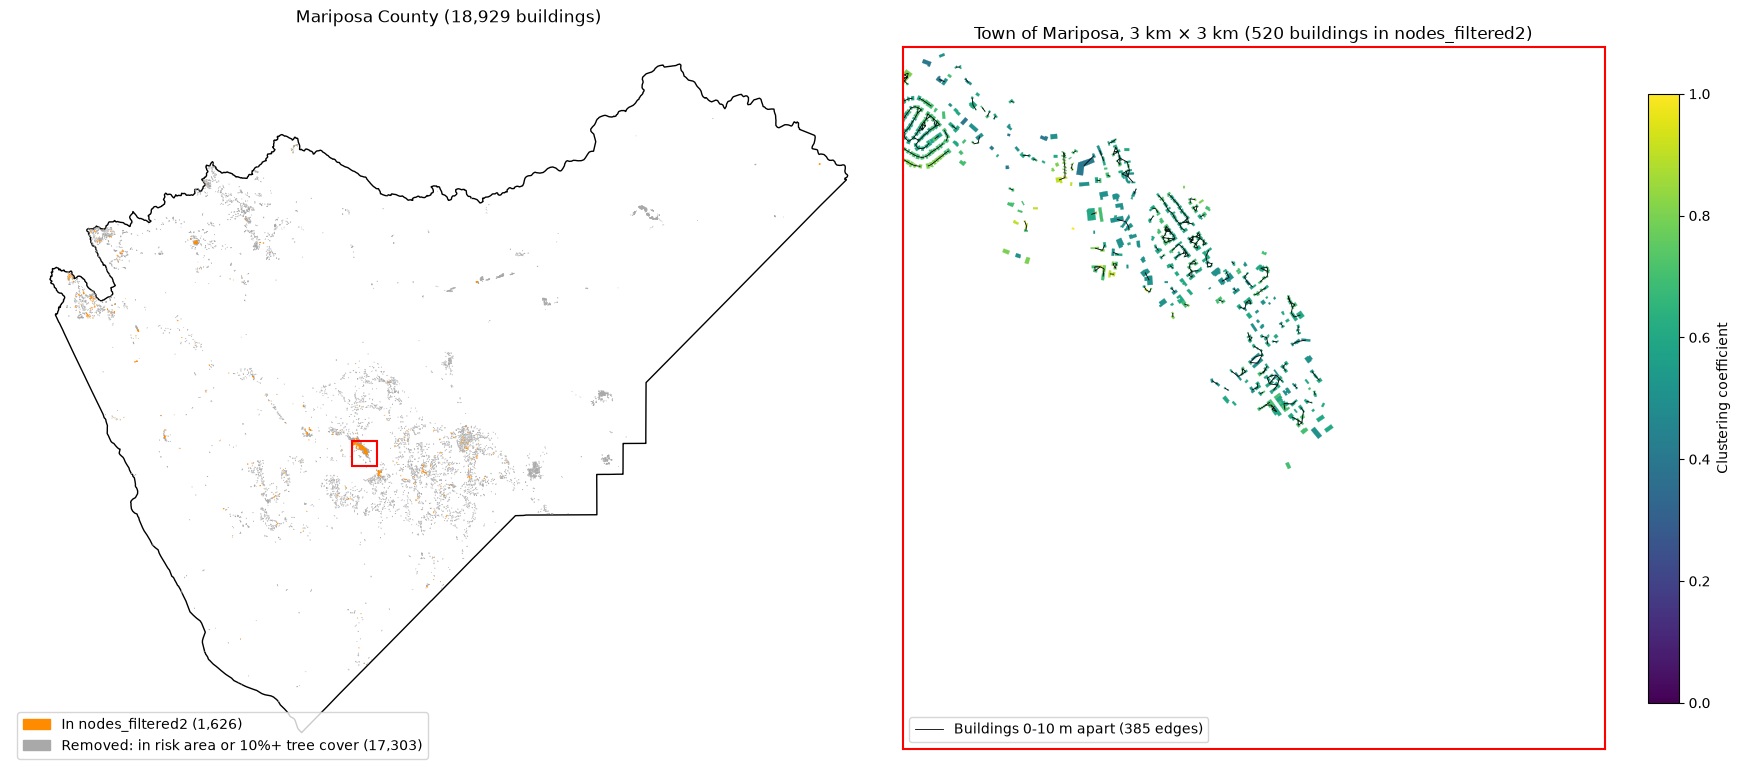

In [41]:
#Map of Mariposa County buildings: all buildings colored by whether they are in nodes_filtered2 (left),
#and nodes_filtered2 buildings in the town of Mariposa colored by clustering coefficient, with the 0-10 m edges (right)

mariposa_all = nodes[nodes["county"] == "Mariposa"]
#nodes_filtered2 kept the row labels from nodes, so this marks which Mariposa buildings passed both filters
in_filtered2 = mariposa_all.index.isin(nodes_filtered2.index)
mariposa_buildings = mariposa_all[in_filtered2]
mariposa_outline = counties[counties["county"] == "Mariposa"]

#Zoom window: a 3 km square centered on the town of Mariposa
town_center = gpd.GeoSeries([Point(-119.9663, 37.4849)], crs="EPSG:4326").to_crs(nodes.crs).iloc[0]
half_width = 1500  # meters
xmin, xmax = town_center.x - half_width, town_center.x + half_width
ymin, ymax = town_center.y - half_width, town_center.y + half_width
town_buildings = mariposa_buildings.cx[xmin:xmax, ymin:ymax]

#Edges 0-10 m apart where both buildings are nodes_filtered2 buildings in the town panel
town_ids = town_buildings["objectid"]
town_edges = edges_0_10[edges_0_10["objectid1"].isin(town_ids) & edges_0_10["objectid2"].isin(town_ids)]
#Draw each edge as a line between the two buildings' centroids (what the dataset's wkt_edge lines connect)
town_centroids = town_buildings.set_index("objectid").geometry.centroid
start = town_centroids.loc[town_edges["objectid1"]]
end = town_centroids.loc[town_edges["objectid2"]]
edge_segments = np.stack([np.column_stack([start.x, start.y]), np.column_stack([end.x, end.y])], axis=1)

fig, (ax_county, ax_town) = plt.subplots(1, 2, figsize=(18, 9))

#County panel: every Mariposa building, colored by whether it is in nodes_filtered2.
#At this scale most buildings are smaller than a pixel, so outline each one in its fill color to keep it visible
removed_color, kept_color = "darkgrey", "darkorange"
mariposa_outline.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax_county)
mariposa_all[~in_filtered2].plot(color=removed_color, edgecolor="face", linewidth=0.5, ax=ax_county)
mariposa_buildings.plot(color=kept_color, edgecolor="face", linewidth=0.5, ax=ax_county) #Drawn on top so they stay visible
ax_county.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, edgecolor="red", linewidth=1.5))
ax_county.legend(
    handles=[
        Patch(color=kept_color, label=f"In nodes_filtered2 ({in_filtered2.sum():,})"),
        Patch(color=removed_color, label=f"Removed: in risk area or 10%+ tree cover ({(~in_filtered2).sum():,})"),
    ],
    loc="lower left",
)
ax_county.set_title(f"Mariposa County ({len(mariposa_all):,} buildings)")
ax_county.set_axis_off()

#Town panel: nodes_filtered2 buildings only, colored by clustering coefficient, with the 0-10 m edges on top
edge_color = "black"
town_buildings.plot(
    column="clustering_coef",
    cmap="viridis",
    vmin=0,
    vmax=1,
    edgecolor="face",
    linewidth=0.2,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend=True,
    legend_kwds={"label": "Clustering coefficient", "shrink": 0.7},
    ax=ax_town,
)
ax_town.add_collection(LineCollection(edge_segments, colors=edge_color, linewidths=0.6))
ax_town.legend(handles=[Line2D([], [], color=edge_color, linewidth=0.6, label=f"Buildings 0-10 m apart ({len(town_edges):,} edges)")],
               loc="lower left")
ax_town.set_xlim(xmin, xmax)
ax_town.set_ylim(ymin, ymax)
ax_town.set_title(f"Town of Mariposa, 3 km × 3 km ({len(town_buildings):,} buildings in nodes_filtered2)")
#Hide the ticks but keep a red frame to match the box on the county panel
ax_town.set_xticks([])
ax_town.set_yticks([])
for spine in ax_town.spines.values():
    spine.set_edgecolor("red")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

## Conclusion
In this initial data exploration, I focused on understanding how much data are available overall, general characteristics of the data and how these differ between ecoregions and counties, how much data are in areas where building connectivity might have an important role in wildfire spread in urban areas, and whether including structure connectivity would change Open Climate Risk’s current risk assessments.

There are a lot of data, and it is a rich dataset. As expected, the neighbor counts (the number of buildings within 10, 50, and 100 m) are all strongly correlated with each other, with the counts within 50 m and 100 m likely being too correlated to both be included as predictors in the same simple model. The actual buildings could be included in a more complex graph theory model. The clustering coefficient (how connected a building’s neighbors are to each other) has essentially no correlation with the number of buildings within 10 m and weak negative correlations with the counts within 50 m and 100 m (Spearman −0.14 and −0.29), and it is moderately negatively correlated with the mean separation distance to neighboring buildings (−0.60). Within counties and ecoregions, the general pattern of correlations between attributes is also similar (though the strength of the correlations differs). County-average neighbor counts and clustering coefficients are also negatively correlated. For example, Los Angeles and San Francisco have the lowest county-average clustering coefficients but the highest neighbor counts, and Mariposa, where Yosemite National Park is located, has the highest average clustering coefficient but low neighbor counts. This surprised me at first, but it follows from how the clustering coefficient is measured on the 100 m network: urban buildings have dozens of neighbors spread across an area, and many pairs of those neighbors are more than 100 m apart, so they are not connected to each other, which lowers clustering. I would suspect that rural buildings tend to sit in small, tight groups where nearly every neighbor is within 100 m of every other neighbor. The neighbor counts are generally right-skewed, but the clustering coefficient and mean separation distance appear more normally distributed (I did not do a formal test). 

Structure connectivity should have less impact in areas where other factors strongly influence wildfire spread, so I also did some general exploration of how much data exist in urban (non-wildland) areas outside of areas where wildfire spread is likely highly influenced by other factors. First, I looked at the Riley et al. (2025) burn probability dataset and identified which structures were within its wildland risk area, which I defined as any 270 m pixel with a burn probability above 0. Riley et al. set burn probability to exactly 0 where the landscape is treated as nonburnable (urban cores, water, and most agriculture), which is part of why Open Climate Risk spreads risk from wildlands into developed areas. Since we are interested in building on this dataset and expanding it to urban areas (like what is done in Open Climate Risk), I filtered out the buildings already in the Riley et al. (2025) risk area as a proxy for wildlands. Setting one distance seemed flawed, but I did observe that 39% of all buildings are outside of the Riley et al. risk area but within 500 m of it, which is a substantial amount of data to use for research (distances are only accurate to within a few hundred meters because of the 270 m pixels). I also removed structures within areas that have 10% or greater tree cover (10% canopy cover is the threshold the UN FAO and the USDA Forest Service use to define forest) under the assumption that if there are enough trees to help the fire spread, then the connectivity of structures does not matter. That removed 26.7% of the 11.1 million buildings outside of the Riley et al. risk area, leaving about 8.1 million, so a lot of buildings are outside of the wildland risk area and outside of dense forest canopies. This was just the start and does not consider a variety of other important factors, including non-tree vegetation causing fire spread, buildings within wildland areas that were deemed to not have a wildfire risk in Riley et al. (2025), topography with relation to fire direction (if structures are uphill of a fire, then connectivity probably does not matter much since they have such a high risk already), and wind patterns (directions, speed, etc.). 

Similarly, if the goal is to improve Open Climate Risk’s risk estimates, I wanted to explore whether building connectivity could add risk information not already captured. For example, if highly connected buildings are usually in areas already deemed high risk and sparser buildings in areas deemed low risk, then it would be harder to identify a structure connectivity signal on fire spread. Thus, I looked at three counties to see if Open Climate Risk’s 2047 fire risk estimates were correlated with the structure connectivity attributes, using only the filtered buildings described above (outside the Riley et al. risk area and with less than 10% tree cover). There were no high correlations for the counties of Sacramento, Shasta, or Mariposa; the strongest was a Spearman correlation of −0.41 (the number of buildings within 50 m in Shasta). The Mariposa sample was small, since only 1,626 buildings (about 9% of the county) passed the filters. Sacramento especially has very low correlations, but 71% of its matched buildings have a risk score of 0, so those correlations mostly reflect whether a building has any risk at all. The signs of the correlations also differ between Shasta and Mariposa. In Shasta, buildings with more neighbors have lower risk scores, while in Mariposa they have higher risk scores. The Shasta pattern is likely because dense town centers are far from wildland and the risk scores mostly track distance to wildland. Therefore, spending effort incorporating structure connectivity impacts on fire spread could improve Open Climate Risk’s risk estimates, since connectivity appears to capture information not already reflected in them. 

I also briefly looked at whether county median family income or county percent racial/ethnic minority population (everyone who is not non-Hispanic white) were correlated with any of the structure connectivity metrics. Some were (out of 12 tests across 58 counties, so a few could be significant by chance), but I think the county level is too coarse for this sort of analysis. Some correlations, such as the positive one between the neighbor counts and median family income, are probably more related to urbanization, with cities like LA being more expensive to live in and structurally denser. So to do an exploratory analysis to elucidate any sort of connection, you would need to control for more variables, such as urban versus rural setting, and work at a finer scale, such as census tracts or block groups. That finer-scale analysis could be a useful way to connect structure connectivity with work on climate risk and affordability. 

Some other thoughts about the dataset include that there are not many unique values of the clustering coefficient because it is between 0 and 1 and is only given to one decimal place. When taking the median by county, this number falls to only three values. So this variable might need to be treated as a categorical variable in some analyses. Additionally, the structure graph edges between 70 m and 80 m are not available online. It is unlikely that no buildings have other buildings 70 to 80 m away, so if these data are needed, we would have to reach out to Vibrant Planet. Next, 102,461 buildings (0.75%) have no building ID and no connectivity values, only a footprint. I think these are buildings with no other buildings within 100 m: every building with an ID has at least one neighbor within 100 m, and the buildings without one are concentrated in rural counties (about 6.7% of buildings in Mendocino County versus 0.1% in Los Angeles County). For buildings with IDs, the only variable with missing data is the clustering coefficient (201,768 buildings), which would fit buildings with fewer than two neighbors, since the coefficient needs at least two. Furthermore, in my analysis, some buildings were not assigned an ecoregion or a county. Future analyses would need to be aware that not all of their buildings fall within these common geographical boundaries.
